In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q timm captum shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 9.9 MB/s eta 0:00:00:00:01


In [3]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Imports & Configuration                                    ║
# ╚══════════════════════════════════════════════════════════════════════╝
import os, gc, math, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
import seaborn as sns
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve, f1_score
)
from captum.attr import IntegratedGradients


class CFG:
    # ── Paths ──────────────────────────────────────────────────────────
    CSV_PATH   = "/kaggle/input/datasets/reemalasfar/csv-final/final_preprocessed_data.csv"
    IMAGES_DIR = "/kaggle/input/datasets/ahmedmohsen2005/xai-preprocessed-skin-lesion-17k-dataset/final_processed_images"
    OUTPUT_DIR = "/kaggle/working/efficient_v2_outputs/"

    # ── Columns ────────────────────────────────────────────────────────
    IMG_COL    = "image"
    TARGET_COL = "class"
    DROP_COLS  = [
        "image", "isic_id", "patient_id", "class",
        "diagnosis_confirm_type_histopathology",
        "anatom_site_general_oral/genital",
        "age_group_0-20", "age_group_21-40",
        "age_group_41-60", "age_group_61-85",
        "year",
    ]

    # ── Image ──────────────────────────────────────────────────────────
    IMG_SIZE = 384
    MEAN     = [0.485, 0.456, 0.406]
    STD      = [0.229, 0.224, 0.225]

    # ── Transformer dims ───────────────────────────────────────────────
    D             = 128
    NUM_HEADS     = 8
    FF_DIM        = 256
    NUM_CA_LAYERS = 2
    DROPOUT_TF    = 0.15

    # ── TabTransformer ─────────────────────────────────────────────────
    TAB_DEPTH = 2
    TAB_HEADS = 4

    # ── Backbone ───────────────────────────────────────────────────────
    EFF_MODEL     = "tf_efficientnetv2_s.in21k_ft_in1k"
    FREEZE_BLOCKS = 4

    # ── Training ───────────────────────────────────────────────────────
    SEED          = 42
    EPOCHS        = 40
    BATCH_SIZE    = 16
    NUM_WORKERS = 4
    GRAD_ACCUM    = 2
    PATIENCE      = 10
    LABEL_SMOOTH  = 0.10

    # ── Focal Loss ─────────────────────────────────────────────────────
    FOCAL_ALPHA = 0.25
    FOCAL_GAMMA = 2.0

    # ── Optimiser ──────────────────────────────────────────────────────
    LR_BACKBONE   = 2e-5
    LR_HEAD       = 2e-4
    WEIGHT_DECAY  = 1e-4
    WARMUP_EPOCHS = 3

    # ── Gradual unfreezing ─────────────────────────────────────────────
    UNFREEZE_EPOCH_1 = 10
    UNFREEZE_EPOCH_2 = 20

    # ── EMA ────────────────────────────────────────────────────────────
    EMA_ALPHA = 0.3

    # ── Augmentation mix ───────────────────────────────────────────────
    CUTMIX_PROB  = 0.30
    MIXUP_PROB   = 0.20
    CUTMIX_ALPHA = 1.0
    MIXUP_ALPHA  = 0.4

    # ── TTA ────────────────────────────────────────────────────────────
    TTA_STEPS = 5

    # ── K-Fold ─────────────────────────────────────────────────────────
    USE_KFOLD = False
    N_FOLDS   = 5

    # ── XAI ────────────────────────────────────────────────────────────
    XAI_N_SAMPLES = 5   # per-sample explanations
    XAI_IG_STEPS  = 50  # Integrated Gradients steps
    # XAI always runs on CPU to avoid OOM — GPU is only used for training
    XAI_DEVICE    = "cpu"

    # ── Runtime ────────────────────────────────────────────────────────
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
torch.manual_seed(CFG.SEED)
np.random.seed(CFG.SEED)
print(f"Train device : {CFG.DEVICE}")
print(f"XAI device   : {CFG.XAI_DEVICE}")
print(f"GPU          : {torch.cuda.get_device_name(0) if CFG.DEVICE == 'cuda' else 'N/A'}")

Train device : cuda
XAI device   : cpu
GPU          : Tesla T4


In [4]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Utilities                                                  ║
# ╚══════════════════════════════════════════════════════════════════════╝

def validate_features(df, meta_cols):
    print("\n── Feature validation ──")
    issues = []
    for c in meta_cols:
        if df[c].std() == 0:
            issues.append(f"DEAD COLUMN (zero variance): {c}")
    for c in meta_cols:
        r = abs(df[c].corr(df[CFG.TARGET_COL]))
        if r > 0.45:
            issues.append(f"LEAKAGE RISK (r={r:.3f} with class): {c}")
    if issues:
        for i in issues:
            print(f"  {i}")
        raise ValueError("Fix issues above — add column names to CFG.DROP_COLS.")
    sparse = [(c, (df[c] == 0).mean()) for c in meta_cols
              if (df[c] == 0).mean() > 0.99]
    if sparse:
        print("  Sparse features (>99% zeros) — keeping as missing-data signal:")
        for c, pct in sparse:
            print(f"    {c} ({pct*100:.1f}% zeros)")
    print(f"  Passed — {len(meta_cols)} clean features ready for training.\n")


class EMAMetric:
    def __init__(self, alpha=0.3):
        self.alpha = alpha
        self.value = None

    def update(self, v):
        self.value = v if self.value is None \
            else self.alpha * v + (1 - self.alpha) * self.value
        return self.value


def find_optimal_threshold(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    j        = tpr - fpr
    best_idx = int(np.argmax(j))
    return float(thresholds[best_idx]), float(j[best_idx])

In [5]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Dataset & Sampler                                          ║
# ╚══════════════════════════════════════════════════════════════════════╝

class ISICDataset(Dataset):
    def __init__(self, df, images_dir, augment=False):
        self.df         = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.meta_cols  = [c for c in df.columns if c not in CFG.DROP_COLS]
        self.meta_dim   = len(self.meta_cols)
        self.augment    = augment

        if augment:
            self.transform = transforms.Compose([
                transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.5),
                transforms.RandomRotation(degrees=30),
                transforms.ColorJitter(
                    brightness=0.3, contrast=0.3, saturation=0.3, hue=0.08),
                transforms.RandomGrayscale(p=0.1),
                transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5)),
                transforms.RandomAffine(
                    degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
                transforms.ToTensor(),
                transforms.Normalize(CFG.MEAN, CFG.STD),
                transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                transforms.ToTensor(),
                transforms.Normalize(CFG.MEAN, CFG.STD),
            ])

        self.tta_transforms = [
            transforms.Compose([
                transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                transforms.ToTensor(),
                transforms.Normalize(CFG.MEAN, CFG.STD),
            ]),
            transforms.Compose([
                transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                transforms.RandomHorizontalFlip(p=1.0),
                transforms.ToTensor(),
                transforms.Normalize(CFG.MEAN, CFG.STD),
            ]),
            transforms.Compose([
                transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                transforms.RandomVerticalFlip(p=1.0),
                transforms.ToTensor(),
                transforms.Normalize(CFG.MEAN, CFG.STD),
            ]),
            transforms.Compose([
                transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                transforms.RandomRotation(degrees=(90, 90)),
                transforms.ToTensor(),
                transforms.Normalize(CFG.MEAN, CFG.STD),
            ]),
            transforms.Compose([
                transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
                transforms.RandomRotation(degrees=(270, 270)),
                transforms.ToTensor(),
                transforms.Normalize(CFG.MEAN, CFG.STD),
            ]),
        ]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_name = str(row[CFG.IMG_COL])
        img_path = os.path.join(self.images_dir, img_name)
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Missing: {img_path}")
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        meta  = torch.tensor(
            row[self.meta_cols].values.astype(np.float32), dtype=torch.float32)
        label = torch.tensor(int(row[CFG.TARGET_COL]), dtype=torch.long)
        return image, meta, label


def make_weighted_sampler(labels, epoch=0):
    class_counts  = np.bincount(labels)
    class_weights = 1.0 / class_counts
    sample_w      = class_weights[labels]
    return WeightedRandomSampler(
        weights=torch.from_numpy(sample_w).float(),
        num_samples=len(sample_w),
        replacement=True,
        generator=torch.Generator().manual_seed(CFG.SEED + epoch)
    )

In [6]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Augmentation Mix (CutMix / MixUp)                         ║
# ╚══════════════════════════════════════════════════════════════════════╝

def cutmix_batch(images, labels, alpha=1.0):
    B        = images.size(0)
    lam      = np.random.beta(alpha, alpha)
    rand_idx = torch.randperm(B)
    W, H     = images.size(3), images.size(2)
    cut_w    = int(W * np.sqrt(1 - lam))
    cut_h    = int(H * np.sqrt(1 - lam))
    cx, cy   = np.random.randint(W), np.random.randint(H)
    x1 = max(cx - cut_w // 2, 0);  x2 = min(cx + cut_w // 2, W)
    y1 = max(cy - cut_h // 2, 0);  y2 = min(cy + cut_h // 2, H)
    images_m = images.clone()
    images_m[:, :, y1:y2, x1:x2] = images[rand_idx, :, y1:y2, x1:x2]
    lam = 1 - ((x2 - x1) * (y2 - y1)) / (W * H)
    return images_m, labels, labels[rand_idx], lam


def mixup_batch(images, labels, alpha=0.4):
    lam      = np.random.beta(alpha, alpha)
    rand_idx = torch.randperm(images.size(0))
    mixed    = lam * images + (1 - lam) * images[rand_idx]
    return mixed, labels, labels[rand_idx], lam


def apply_augmentation_mix(images, labels):
    rand = np.random.random()
    if rand < CFG.CUTMIX_PROB:
        images, la, lb, lam = cutmix_batch(images, labels, CFG.CUTMIX_ALPHA)
        return images, la, lb, lam, True
    elif rand < CFG.CUTMIX_PROB + CFG.MIXUP_PROB:
        images, la, lb, lam = mixup_batch(images, labels, CFG.MIXUP_ALPHA)
        return images, la, lb, lam, True
    else:
        return images, labels, labels, 1.0, False

In [7]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Model Architecture                                         ║
# ║  EfficientNetV2Encoder + TabTransformerEncoder + GatedFusionBlock    ║
# ╚══════════════════════════════════════════════════════════════════════╝

class EfficientNetV2Encoder(nn.Module):
    def __init__(self, out_dim=128, dropout=0.15):
        super().__init__()
        self.backbone = timm.create_model(
            CFG.EFF_MODEL, pretrained=True, num_classes=0, global_pool="")
        self._freeze_blocks(CFG.FREEZE_BLOCKS)

        with torch.no_grad():
            dummy         = torch.zeros(1, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
            feats         = self.backbone(dummy)
            self.feat_dim = feats.shape[1]
            self.feat_h   = feats.shape[2]
            self.feat_w   = feats.shape[3]
            print(f"  EfficientNetV2-S feature map: "
                  f"{self.feat_dim}×{self.feat_h}×{self.feat_w} "
                  f"→ {self.feat_h * self.feat_w} spatial tokens")

        self.proj = nn.Sequential(
            nn.Conv2d(self.feat_dim, out_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_dim),
            nn.GELU(),
            nn.Dropout2d(dropout),
        )
        n_patches    = self.feat_h * self.feat_w
        self.pos_emb = nn.Parameter(torch.zeros(1, n_patches, out_dim))
        nn.init.trunc_normal_(self.pos_emb, std=0.02)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, out_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def _freeze_blocks(self, n_freeze):
        for param in self.backbone.conv_stem.parameters():
            param.requires_grad = False
        for param in self.backbone.bn1.parameters():
            param.requires_grad = False
        for i in range(n_freeze):
            for name, param in self.backbone.named_parameters():
                if name.startswith(f"blocks.{i}."):
                    param.requires_grad = False

    def unfreeze_blocks(self, from_block, to_block):
        for i in range(from_block, to_block):
            for name, param in self.backbone.named_parameters():
                if name.startswith(f"blocks.{i}."):
                    param.requires_grad = True
        trainable = sum(p.numel() for p in self.backbone.parameters()
                        if p.requires_grad)
        print(f"  🔓 Unfroze blocks {from_block}–{to_block-1} | "
              f"Backbone trainable params: {trainable:,}")

    def get_newly_unfrozen_params(self, from_block, to_block):
        params = []
        for i in range(from_block, to_block):
            for name, param in self.backbone.named_parameters():
                if name.startswith(f"blocks.{i}.") and param.requires_grad:
                    params.append(param)
        return params

    def forward(self, x):
        feats  = self.backbone(x)
        tokens = self.proj(feats)
        B, D, H, W = tokens.shape
        tokens = tokens.flatten(2).transpose(1, 2)
        tokens = tokens + self.pos_emb
        cls    = self.cls_token.expand(B, -1, -1)
        return torch.cat([cls, tokens], dim=1)


class TabTransformerEncoder(nn.Module):
    def __init__(self, num_features, embed_dim=128, depth=2,
                 num_heads=4, ff_dim=256, dropout=0.15):
        super().__init__()
        self.num_features = num_features
        self.feature_embeddings = nn.ModuleList([
            nn.Sequential(nn.Linear(1, embed_dim), nn.LayerNorm(embed_dim))
            for _ in range(num_features)
        ])
        self.pos_emb   = nn.Parameter(torch.zeros(1, num_features, embed_dim))
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.pos_emb,   std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            activation="gelu", batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm        = nn.LayerNorm(embed_dim)

    def forward(self, x):
        B      = x.size(0)
        tokens = torch.stack([
            self.feature_embeddings[i](x[:, i:i+1])
            for i in range(self.num_features)
        ], dim=1)
        tokens = tokens + self.pos_emb
        cls    = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        tokens = self.transformer(tokens)
        return self.norm(tokens)


class GatedFusionBlock(nn.Module):
    """
    Replaces CrossAttentionBlock.
    g = sigmoid( Linear(2D→D)([img_cls ; meta_cls]) )
    img_cls  ← g*img_cls  + (1-g)*meta_cls
    meta_cls ← (1-g)*meta_cls + g*img_cls
    gate_proxy returned as (B,1,1,D) to keep downstream shape assumptions.
    """
    def __init__(self, dim, num_heads, ff_dim, dropout=0.15):
        super().__init__()
        self.dim = dim

        self.gate_net = nn.Sequential(
            nn.LayerNorm(dim * 2),
            nn.Linear(dim * 2, dim),
            nn.Sigmoid(),
        )
        self.img_self_attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.norm_img  = nn.LayerNorm(dim)
        self.ffn_img   = nn.Sequential(
            nn.LayerNorm(dim), nn.Linear(dim, ff_dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(ff_dim, dim), nn.Dropout(dropout),
        )
        self.ffn_meta  = nn.Sequential(
            nn.LayerNorm(dim), nn.Linear(dim, ff_dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(ff_dim, dim), nn.Dropout(dropout),
        )
        self._last_gate = None

    def forward(self, img_tokens, meta_tokens):
        # 1. Image patch self-attention
        img_sa, _ = self.img_self_attn(
            query=self.norm_img(img_tokens),
            key=img_tokens, value=img_tokens,
            need_weights=False
        )
        img_tokens = img_tokens + img_sa

        # 2. CLS tokens
        img_cls  = img_tokens[:, 0, :]
        meta_cls = meta_tokens[:, 0, :]

        # 3. Gate
        gate = self.gate_net(torch.cat([img_cls, meta_cls], dim=-1))
        self._last_gate = gate.detach()

        # 4. Gated blend
        new_img_cls  = gate * img_cls  + (1.0 - gate) * meta_cls
        new_meta_cls = (1.0 - gate) * meta_cls + gate * img_cls

        # 5. Residual + FFN
        img_tokens_updated = img_tokens.clone()
        img_tokens_updated[:, 0, :] = img_cls + self.ffn_img(new_img_cls)

        meta_tokens_updated = meta_tokens.clone()
        meta_tokens_updated[:, 0, :] = meta_cls + self.ffn_meta(new_meta_cls)

        # 6. gate_proxy shape (B,1,1,D) for downstream compat
        gate_proxy = gate.unsqueeze(1).unsqueeze(1)
        return img_tokens_updated, meta_tokens_updated, gate_proxy


class EfficientFusionModel(nn.Module):
    def __init__(self, meta_dim):
        super().__init__()
        D = CFG.D
        self.img_encoder  = EfficientNetV2Encoder(out_dim=D, dropout=CFG.DROPOUT_TF)
        self.meta_encoder = TabTransformerEncoder(
            num_features=meta_dim, embed_dim=D,
            depth=CFG.TAB_DEPTH, num_heads=CFG.TAB_HEADS,
            ff_dim=CFG.FF_DIM, dropout=CFG.DROPOUT_TF
        )
        self.ca_layers = nn.ModuleList([
            GatedFusionBlock(
                dim=D, num_heads=CFG.NUM_HEADS,
                ff_dim=CFG.FF_DIM, dropout=CFG.DROPOUT_TF
            )
            for _ in range(CFG.NUM_CA_LAYERS)
        ])
        self.classifier = nn.Sequential(
            nn.LayerNorm(D * 2),
            nn.Linear(D * 2, 256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 128),   nn.GELU(), nn.Dropout(0.2),
            nn.Linear(128, 2),
        )
        self._attn_weights = None

    def forward(self, image, meta):
        img_tokens  = self.img_encoder(image)
        meta_tokens = self.meta_encoder(meta)
        for ca in self.ca_layers:
            img_tokens, meta_tokens, attn = ca(img_tokens, meta_tokens)
        self._attn_weights = attn.detach()
        img_cls  = img_tokens[:, 0, :]
        meta_cls = meta_tokens[:, 0, :]
        fused    = torch.cat([img_cls, meta_cls], dim=1)
        return self.classifier(fused)

    def get_attention_weights(self):
        return self._attn_weights

    def unfreeze_backbone_blocks(self, from_block, to_block):
        self.img_encoder.unfreeze_blocks(from_block, to_block)

    def get_newly_unfrozen_params(self, from_block, to_block):
        return self.img_encoder.get_newly_unfrozen_params(from_block, to_block)

In [8]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Loss Functions & LR Scheduler                              ║
# ╚══════════════════════════════════════════════════════════════════════╝

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, smoothing=0.05):
        super().__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.smoothing = smoothing

    def forward(self, logits, targets):
        n  = logits.size(1)
        lp = F.log_softmax(logits, dim=1)
        with torch.no_grad():
            s = torch.full_like(lp, self.smoothing / (n - 1))
            s.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        ce   = -(s * lp).sum(dim=1)
        pt   = torch.exp(-ce)
        loss = self.alpha * (1 - pt) ** self.gamma * ce
        return loss.mean()


class MixLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, smoothing=0.05):
        super().__init__()
        self.focal = FocalLoss(alpha, gamma, smoothing)

    def forward(self, logits, targets_a, targets_b=None, lam=1.0):
        if targets_b is None or lam == 1.0:
            return self.focal(logits, targets_a)
        return (lam * self.focal(logits, targets_a) +
                (1 - lam) * self.focal(logits, targets_b))


class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=1e-6):
        self.opt            = optimizer
        self.warmup_epochs  = warmup_epochs
        self.total_epochs   = total_epochs
        self.min_lr         = min_lr
        self.base_lrs       = [pg["lr"] for pg in optimizer.param_groups]
        self._current_epoch = 0

    def add_new_param_group(self, lr):
        self.base_lrs.append(lr)

    def step(self, epoch):
        self._current_epoch = epoch
        e = epoch - 1
        if e < self.warmup_epochs:
            scale = max(0.01, (e + 1) / self.warmup_epochs)
        else:
            progress  = (e - self.warmup_epochs) / \
                        max(1, self.total_epochs - self.warmup_epochs)
            min_scale = self.min_lr / max(self.base_lrs)
            scale     = max(0.5 * (1 + math.cos(math.pi * progress)), min_scale)
        for pg, base in zip(self.opt.param_groups, self.base_lrs):
            pg["lr"] = base * scale

    def get_lr(self):
        return [pg["lr"] for pg in self.opt.param_groups]

In [9]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Train / Eval Loops                                         ║
# ╚══════════════════════════════════════════════════════════════════════╝

def train_one_epoch(model, loader, optimizer, criterion, scaler_amp, device):
    model.train()
    total_loss = 0
    all_labels, all_probs = [], []
    optimizer.zero_grad(set_to_none=True) # Optimized zero_grad

    # tqdm added for progress tracking
    pbar = tqdm(loader, desc="  Train", leave=False)
    for step, (images, metas, labels) in enumerate(pbar):

        # non_blocking=True works with pinned memory for faster transfer
        images = images.to(device, non_blocking=True)
        metas  = metas.to(device,  non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        images, labels_a, labels_b, lam, use_mix = apply_augmentation_mix(images, labels)

        # Mixed Precision Context
        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            logits = model(images, metas)
            loss   = criterion(logits, labels_a, labels_b if use_mix else None, lam) 
            loss   = loss / CFG.GRAD_ACCUM

        # Scaled Backpropagation
        scaler_amp.scale(loss).backward()

        if (step + 1) % CFG.GRAD_ACCUM == 0:
            scaler_amp.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            scaler_amp.step(optimizer)
            scaler_amp.update()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * CFG.GRAD_ACCUM * images.size(0)
        
        # Move back to CPU only for metrics to save GPU bandwidth
        probs = torch.softmax(logits, dim=1)[:, 1].detach().float().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels_a.cpu().numpy())
        
        pbar.set_postfix(loss=f"{loss.item()*CFG.GRAD_ACCUM:.4f}")

    avg_loss = total_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, auc


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0
    all_labels, all_probs, all_preds = [], [], []

    for images, metas, labels in tqdm(loader, desc="  Val  ", leave=False):
        images = images.to(device, non_blocking=True)
        metas  = metas.to(device,  non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            logits = model(images, metas)
            loss   = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        probs = torch.softmax(logits, dim=1)[:, 1].float().cpu().numpy()
        preds = (probs >= threshold).astype(int)
        all_probs.extend(probs);  all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss  = total_loss / len(loader.dataset)
    labels_np = np.array(all_labels)
    probs_np  = np.array(all_probs)
    preds_np  = np.array(all_preds)
    auc       = roc_auc_score(labels_np, probs_np)
    f1        = f1_score(labels_np, preds_np, average="macro")
    return avg_loss, auc, f1, labels_np, preds_np, probs_np


@torch.no_grad()
def evaluate_with_tta(model, dataset, criterion, device, threshold=0.5):
    model.eval()
    all_labels, all_probs = [], []
    loader = DataLoader(dataset, batch_size=CFG.BATCH_SIZE, shuffle=False,
                        num_workers=CFG.NUM_WORKERS, pin_memory=True)
    print("  Running TTA inference...")
    for tta_idx, tta_tf in enumerate(dataset.tta_transforms):
        dataset.transform = tta_tf
        tta_probs = []
        for images, metas, labels in tqdm(
                loader,
                desc=f"  TTA {tta_idx+1}/{len(dataset.tta_transforms)}",
                leave=False):
            images = images.to(device, non_blocking=True)
            metas  = metas.to(device,  non_blocking=True)
            with torch.amp.autocast("cuda", enabled=(device == "cuda")):
                logits = model(images, metas)
            probs = torch.softmax(logits, dim=1)[:, 1].float().cpu().numpy()
            tta_probs.extend(probs)
            if tta_idx == 0:
                all_labels.extend(labels.numpy())
        all_probs.append(np.array(tta_probs))
    dataset.transform = dataset.tta_transforms[0]
    avg_probs = np.mean(all_probs, axis=0)
    labels_np = np.array(all_labels)
    auc       = roc_auc_score(labels_np, avg_probs)
    preds_np  = (avg_probs >= threshold).astype(int)
    f1        = f1_score(labels_np, preds_np, average="macro")
    print(f"  TTA AUC: {auc:.4f}  F1: {f1:.4f}")
    return auc, f1, labels_np, preds_np, avg_probs

In [10]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Plot Helpers                                               ║
# ╚══════════════════════════════════════════════════════════════════════╝

def plot_training_curves(history, fold=None):
    tag = f"_fold{fold}" if fold else ""
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    axes[0].plot(history["train_loss"], label="Train", marker="o", ms=3)
    axes[0].plot(history["val_loss"],   label="Val",   marker="o", ms=3)
    axes[0].set_title("Focal Loss"); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(history["train_auc"],   label="Train raw",  ms=3, alpha=0.4)
    axes[1].plot(history["val_auc"],     label="Val raw",    ms=3, alpha=0.4)
    axes[1].plot(history["val_auc_ema"], label="Val EMA", lw=2)
    axes[1].set_title("AUC-ROC"); axes[1].legend(); axes[1].grid(True)
    axes[2].plot(history["val_f1"], label="Val F1", color="green", ms=3)
    axes[2].set_title("Val F1 macro"); axes[2].legend(); axes[2].grid(True)
    axes[3].plot(history["threshold"], label="Youden-J threshold",
                 color="purple", ms=3)
    axes[3].axhline(0.5, color="gray", linestyle="--", alpha=0.5,
                    label="Default 0.5")
    axes[3].set_title("Optimal threshold"); axes[3].legend(); axes[3].grid(True)
    plt.suptitle(
        f"EfficientNetV2-S × TabTransformer (Gated Fusion)"
        f"{' | Fold '+str(fold) if fold else ''}",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    path = os.path.join(CFG.OUTPUT_DIR, f"training_curves_efficient_v2{tag}.png")
    plt.savefig(path, dpi=150); plt.show(); plt.close()
    print(f"  Saved: {path}")


def plot_confusion_matrix(labels, preds, threshold, fold=None):
    tag = f"_fold{fold}" if fold else ""
    cm  = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Non-Melanoma", "Melanoma"],
                yticklabels=["Non-Melanoma", "Melanoma"], ax=ax)
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    ax.set_title(f"Confusion Matrix (threshold={threshold:.3f})")
    plt.tight_layout()
    path = os.path.join(CFG.OUTPUT_DIR,
                        f"confusion_matrix_efficient_v2{tag}.png")
    plt.savefig(path, dpi=150); plt.show(); plt.close()


def plot_roc_curve(labels, probs, auc_score, threshold, fold=None):
    tag = f"_fold{fold}" if fold else ""
    fpr, tpr, _ = roc_curve(labels, probs)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, lw=2, color="steelblue",
            label=f"AUC = {auc_score:.4f}")
    ax.plot([0, 1], [0, 1], "k--")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"ROC Curve (optimal threshold={threshold:.3f})")
    ax.legend(); ax.grid(True)
    plt.tight_layout()
    path = os.path.join(CFG.OUTPUT_DIR,
                        f"roc_curve_efficient_v2{tag}.png")
    plt.savefig(path, dpi=150); plt.show(); plt.close()

In [11]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — XAI Suite (CPU-safe)                                      ║
# ║                                                                      ║
# ║  ALL XAI runs on CFG.XAI_DEVICE (cpu) by default.                   ║
# ║  The model is copied to CPU before any attribution call and          ║
# ║  the GPU copy is left untouched for the next training run.           ║
# ║                                                                      ║
# ║  Methods:                                                            ║
# ║    1. Grad-CAM / Grad-CAM++                                          ║
# ║    2. Integrated Gradients  (image + tabular)                        ║
# ║    3. Attention Rollout  (TabTransformer self-attn)                  ║
# ║    4. Gate Values  (GatedFusionBlock diagnostic)                     ║
# ╚══════════════════════════════════════════════════════════════════════╝
import copy

# ── Shared image transform (no device — tensors moved explicitly) ──────
_XAI_TF = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(CFG.MEAN, CFG.STD),
])


# ── Low-level helpers ──────────────────────────────────────────────────
def _norm01(x):
    mn, mx = x.min(), x.max()
    return (x - mn) / (mx - mn + 1e-8)


def _resize_map(arr2d, size):
    pil = Image.fromarray((_norm01(arr2d) * 255).astype(np.uint8))
    return np.array(pil.resize((size, size), Image.BILINEAR)) / 255.0


def _overlay(rgb, heatmap, alpha=0.5):
    colored = mpl_cm.get_cmap("jet")(heatmap)[..., :3]
    return np.clip((1 - alpha) * rgb + alpha * colored, 0, 1)


def _save(fig, name):
    path = os.path.join(CFG.OUTPUT_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  ✔ {path}")


def _xai_load(img_path_or_name, meta_series, device):
    """
    Load one image + meta row onto `device`.
    Returns (img_tensor, meta_tensor, rgb_numpy).
    """
    raw_name   = str(img_path_or_name).split("/")[-1]
    match      = re.search(r"(\d{7})", raw_name)
    clean_name = f"ISIC_{match.group(1)}.jpg" if match else raw_name
    final_path = os.path.join(CFG.IMAGES_DIR, clean_name)
    if not os.path.exists(final_path):
        raise FileNotFoundError(f"XAI could not find image: {final_path}")

    img = Image.open(final_path).convert("RGB")
    it  = _XAI_TF(img).unsqueeze(0).to(device)
    mt  = torch.tensor(
        meta_series.values.astype(np.float32),
        dtype=torch.float32
    ).unsqueeze(0).to(device)
    rgb = (it.squeeze().cpu().permute(1, 2, 0).numpy()
           * np.array(CFG.STD) + np.array(CFG.MEAN))
    return it, mt, np.clip(rgb, 0, 1)


def _cpu_model(gpu_model):
    """
    Return a CPU copy of the model in eval mode.
    The original GPU model is NOT modified.
    """
    m = copy.deepcopy(gpu_model).to("cpu").eval()
    # Detach stored gate tensors so they don't hold GPU memory
    for block in m.ca_layers:
        block._last_gate = None
    return m


# ── XAI 1 & 2: Grad-CAM / Grad-CAM++ ─────────────────────────────────
def _get_last_conv(model):
    last = None
    for m in model.img_encoder.backbone.modules():
        if isinstance(m, nn.Conv2d):
            last = m
    return last


class _GradCAMEngine:
    def __init__(self, model, plus_plus=False):
        self.model     = model
        self.plus_plus = plus_plus
        self._acts = self._grads = None
        tl = _get_last_conv(model)
        self._fh = tl.register_forward_hook(
            lambda m, i, o: setattr(self, "_acts", o.detach()))
        self._bh = tl.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "_grads", go[0].detach()))

    def remove(self):
        self._fh.remove(); self._bh.remove()

    def __call__(self, img_t, meta_t, class_idx=1):
        self.model.zero_grad()
        logits = self.model(img_t, meta_t)
        logits[0, class_idx].backward()
        g, a = self._grads, self._acts
        if self.plus_plus:
            g2    = g ** 2;  g3 = g ** 3
            denom = 2 * g2 + g3 * a.sum(dim=(2, 3), keepdim=True) + 1e-8
            w     = (g2 / denom * F.relu(g)).sum(dim=(2, 3), keepdim=True)
        else:
            w = g.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * a).sum(dim=1).squeeze())
        return _norm01(cam.cpu().numpy())


def xai_gradcam_pp(model, img_t, meta_t, rgb, meta_cols_used,
                   save_tag="", class_idx=1):
    """Runs on whatever device model/tensors are already on (cpu for XAI)."""
    S = rgb.shape[0]
    gc_eng = _GradCAMEngine(model, plus_plus=False)
    gc_map = gc_eng(img_t.clone(), meta_t.clone(), class_idx)
    gc_eng.remove()

    pp_eng = _GradCAMEngine(model, plus_plus=True)
    pp_map = pp_eng(img_t.clone(), meta_t.clone(), class_idx)
    pp_eng.remove()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(rgb);                                       axes[0].set_title("Original")
    axes[1].imshow(_overlay(rgb, _resize_map(gc_map, S)));     axes[1].set_title("Grad-CAM")
    axes[2].imshow(_overlay(rgb, _resize_map(pp_map, S)));     axes[2].set_title("Grad-CAM++")
    for ax in axes: ax.axis("off")
    with torch.no_grad():
        prob = torch.softmax(model(img_t, meta_t), dim=1)[0, class_idx].item()
    fig.suptitle(f"Grad-CAM family  |  P(Melanoma) = {prob:.3f}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    _save(fig, f"xai_gradcam{save_tag}.png")
    return gc_map, pp_map


# ── XAI 3: Integrated Gradients ───────────────────────────────────────
def xai_integrated_gradients(model, img_t, meta_t, rgb, meta_cols_used,
                              save_tag="", class_idx=1, n_steps=None):
    """
    Runs entirely on CPU.
    n_steps is capped at 25 to keep memory reasonable even on CPU.
    """
    if n_steps is None:
        # Cap at 25 steps on CPU: still gives useful attributions
        # without allocating 50 × full feature map copies
        n_steps = min(CFG.XAI_IG_STEPS, 25)

    S      = rgb.shape[0]
    ig_eng = IntegratedGradients(model)
    model.zero_grad()

    attr, delta = ig_eng.attribute(
        inputs=(img_t, meta_t),
        baselines=(torch.zeros_like(img_t), torch.zeros_like(meta_t)),
        target=class_idx,
        n_steps=n_steps,
        return_convergence_delta=True,
    )

    img_attr = attr[0].squeeze().permute(1, 2, 0).detach().numpy()
    img_map  = _norm01(np.abs(img_attr).sum(axis=-1))
    tab_attr = attr[1].squeeze().detach().numpy()
    n_feat   = len(meta_cols_used)

    fig = plt.figure(figsize=(18, 6))
    gs  = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.4])
    ax0, ax1, ax2 = (fig.add_subplot(gs[i]) for i in range(3))

    ax0.imshow(rgb);  ax0.axis("off");  ax0.set_title("Original image")
    ax1.imshow(_overlay(rgb, _resize_map(img_map, S)))
    ax1.axis("off")
    ax1.set_title(f"IG — image\n(Δ={delta.item():.3f}, steps={n_steps})")

    top_k  = min(20, n_feat)
    order  = np.argsort(np.abs(tab_attr))[::-1][:top_k]
    vals   = tab_attr[order][::-1]
    names  = [meta_cols_used[i] for i in order][::-1]
    colors = ["#d6604d" if v > 0 else "#4393c3" for v in vals]
    ax2.barh(range(top_k), vals, color=colors)
    ax2.set_yticks(range(top_k));  ax2.set_yticklabels(names, fontsize=8)
    ax2.axvline(0, color="black", lw=0.8)
    ax2.set_title("IG — tabular\n(red=↑ melanoma, blue=↓ melanoma)")
    ax2.grid(axis="x", alpha=0.3)

    with torch.no_grad():
        prob = torch.softmax(model(img_t, meta_t), dim=1)[0, class_idx].item()
    fig.suptitle(
        f"Integrated Gradients (multimodal)  |  P(Melanoma) = {prob:.3f}",
        fontsize=13, fontweight="bold")
    plt.tight_layout()
    _save(fig, f"xai_integrated_gradients{save_tag}.png")
    return img_attr, tab_attr


# ── XAI 4: Attention Rollout + Gate overlay ───────────────────────────
def xai_attention_rollout(model, img_t, meta_t, rgb, meta_cols_used,
                          feat_h, feat_w, save_tag=""):
    """
    TabTransformer self-attention rollout + gated fusion mean gate overlay.
    Hooks use need_weights=True only on the TabTransformer sa layers.
    The GatedFusionBlock gate is captured via a forward hook on the block.
    """
    S     = rgb.shape[0]
    store = {}
    hooks = []

    # Tab self-attention hooks (nn.MultiheadAttention returns (out, weights))
    def _make_sa_hook(name):
        def _h(module, inp, out):
            # out[1] is the attn weight tensor (or None if need_weights=False)
            if isinstance(out, tuple) and len(out) >= 2 and out[1] is not None:
                store[name] = out[1].detach().cpu().float()
        return _h

    for i, layer in enumerate(model.meta_encoder.transformer.layers):
        hooks.append(
            layer.self_attn.register_forward_hook(_make_sa_hook(f"tab_sa_{i}"))
        )

    # GatedFusionBlock hook — captures gate_proxy from forward output index 2
    def _gate_hook(module, inp, out):
        store["cross_attn"] = out[2].detach().cpu().float()

    hooks.append(model.ca_layers[-1].register_forward_hook(_gate_hook))

    with torch.no_grad():
        model(img_t, meta_t)
    for h in hooks:
        h.remove()

    # ── Rollout across TabTransformer layers ──────────────────────────
    sa_keys = sorted(k for k in store if k.startswith("tab_sa_"))
    rollout = None
    for k in sa_keys:
        attn = store[k][0].mean(dim=0)          # average over heads
        I    = torch.eye(attn.shape[0])
        attn = (attn + I)
        attn = attn / (attn.sum(dim=-1, keepdim=True) + 1e-8)
        rollout = attn if rollout is None else torch.matmul(attn, rollout)

    n_meta = len(meta_cols_used)

    # ── Gate overlay (uniform spatial map tinted by mean gate) ────────
    cross_overlay = mean_gate = None
    if "cross_attn" in store:
        gate_vec  = store["cross_attn"][0, 0, 0, :].numpy()
        mean_gate = float(gate_vec.mean())
        spatial   = np.full((feat_h, feat_w), mean_gate)
        cross_overlay = _resize_map(spatial, S)

    fig, axes = plt.subplots(1, 3, figsize=(21, 6))

    # Panel 1 — Rollout matrix
    if rollout is not None:
        n_show = min(rollout.shape[0], n_meta + 1)
        mat    = rollout[:n_show, :n_show].numpy()
        im     = axes[0].imshow(mat, cmap="Blues", aspect="auto")
        ticks  = ["CLS"] + list(meta_cols_used[:n_show - 1])
        axes[0].set_xticks(range(n_show));  axes[0].set_yticks(range(n_show))
        axes[0].set_xticklabels(ticks, rotation=90, fontsize=7)
        axes[0].set_yticklabels(ticks, fontsize=7)
        plt.colorbar(im, ax=axes[0], fraction=0.046)
        axes[0].set_title("Attention Rollout\nTabTransformer (token×token)",
                          fontsize=10)
    else:
        axes[0].axis("off");  axes[0].set_title("Rollout unavailable")

    # Panel 2 — CLS → feature bar
    if rollout is not None and rollout.shape[0] > 1:
        cls_feat = rollout[0, 1:n_meta + 1].numpy()
        colors2  = mpl_cm.viridis(cls_feat / (cls_feat.max() + 1e-8))
        axes[1].bar(range(n_meta), cls_feat, color=colors2)
        axes[1].set_xticks(range(n_meta))
        axes[1].set_xticklabels(meta_cols_used, rotation=90, fontsize=7)
        axes[1].set_title(
            "CLS → feature attention\n(how much CLS attends to each feature)",
            fontsize=10)
        axes[1].grid(axis="y", alpha=0.3)
    else:
        axes[1].axis("off")

    # Panel 3 — Gate overlay
    if cross_overlay is not None:
        axes[2].imshow(_overlay(rgb, cross_overlay, alpha=0.55))
        axes[2].set_title(
            f"Gated Fusion — mean gate: {mean_gate:.3f}\n"
            "(1=image dominates, 0=metadata dominates)", fontsize=10)
    else:
        axes[2].imshow(rgb);  axes[2].set_title("Gate info unavailable")
    axes[2].axis("off")

    fig.suptitle("Attention Rollout + Gated Fusion Analysis",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    _save(fig, f"xai_attention_rollout{save_tag}.png")
    return rollout, cross_overlay


# ── XAI 5: Gate Values per channel ────────────────────────────────────
def xai_gate_values(model, img_t, meta_t, meta_cols_used, save_tag=""):
    """
    Visualise g ∈ (0,1)^D for each GatedFusionBlock.
    g ≈ 1 → image stream dominates that channel.
    """
    model.eval()
    with torch.no_grad():
        model(img_t, meta_t)

    n_layers = len(model.ca_layers)
    fig, axes = plt.subplots(1, n_layers, figsize=(8 * n_layers, 4))
    if n_layers == 1:
        axes = [axes]

    for i, block in enumerate(model.ca_layers):
        gate = block._last_gate
        if gate is None:
            axes[i].set_title(f"Layer {i}: no gate stored"); continue
        g = gate[0].cpu().numpy()
        axes[i].bar(range(len(g)), g, color=mpl_cm.coolwarm(g))
        axes[i].axhline(0.5, color="black", lw=0.8, linestyle="--",
                        label="g=0.5 (equal blend)")
        axes[i].set_ylim(0, 1)
        axes[i].set_xlabel("Embedding channel")
        axes[i].set_ylabel("Gate value  g  (1=image, 0=meta)")
        axes[i].set_title(f"Gated Fusion Layer {i+1}\n"
                          f"mean g={g.mean():.3f}  "
                          f"(image weight: {g.mean()*100:.1f}%)")
        axes[i].legend(fontsize=8)

    with torch.no_grad():
        prob = torch.softmax(model(img_t, meta_t), dim=1)[0, 1].item()
    fig.suptitle(f"Gate Values per Fusion Layer  |  P(Melanoma)={prob:.3f}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    _save(fig, f"xai_gate_values{save_tag}.png")


# ── Built-in gate plots (called from run_training) ─────────────────────
def plot_attention_heatmap(attn_weights, meta_cols, sample_idx=0,
                           save_path=None):
    gate   = attn_weights[sample_idx, 0, 0, :].cpu().numpy()
    n      = len(gate)
    colors = plt.cm.RdYlBu_r(gate / (gate.max() + 1e-8))
    fig, ax = plt.subplots(figsize=(max(10, n // 4), 3))
    ax.bar(range(n), gate, color=colors)
    ax.set_xlabel("Embedding channel")
    ax.set_ylabel("Gate value  g  (1=image, 0=meta)")
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="black", lw=0.8, linestyle="--")
    ax.set_title("Gated Fusion: per-channel gate values\n"
                 "(gate≈1 means image dominates)")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_spatial_attention_map(attn_weights, raw_img_np, feat_h, feat_w,
                               sample_idx=0, save_path=None):
    gate      = attn_weights[sample_idx, 0, 0, :].cpu().numpy()
    mean_gate = float(gate.mean())
    spatial   = np.full((feat_h, feat_w), mean_gate)
    spatial_up = np.array(
        Image.fromarray(
            (spatial / (spatial.max() + 1e-8) * 255).astype(np.uint8)
        ).resize((CFG.IMG_SIZE, CFG.IMG_SIZE), Image.BILINEAR)
    ) / 255.0
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(raw_img_np); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].bar(range(len(gate)), gate, color=mpl_cm.coolwarm(gate))
    axes[1].set_title(f"Gate values (D={len(gate)})\nmean={mean_gate:.3f}")
    axes[1].set_ylim(0, 1)
    axes[1].axhline(0.5, color="k", lw=0.8, linestyle="--")
    axes[2].imshow(raw_img_np)
    axes[2].imshow(spatial_up, cmap="hot", alpha=0.3)
    axes[2].set_title(
        f"Gated Fusion overlay  mean={mean_gate:.3f}\n"
        f"({'image-dominant' if mean_gate > 0.5 else 'meta-dominant'})")
    axes[2].axis("off")
    plt.suptitle("Gated Fusion Analysis", fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


# ── XAI Orchestrator ──────────────────────────────────────────────────
def run_all_xai(gpu_model, val_df, meta_cols_used, feat_h, feat_w, fold=None):
    """
    Per-sample XAI.  The GPU model is deep-copied to CPU before any
    attribution work so GPU memory is never touched during XAI.
    """
    tag_fold = f"_fold{fold}" if fold else ""
    xai_dev  = CFG.XAI_DEVICE          # "cpu"

    print(f"\n{'═'*65}")
    print(f"  XAI Suite  ({'Fold '+str(fold) if fold else 'Single run'})")
    print(f"  Running on : {xai_dev.upper()}  "
          f"(GPU left free — no OOM risk)")
    print(f"  Methods    : Grad-CAM++, IG (multimodal), "
          f"Attention Rollout, Gate Values")
    print(f"  Samples    : {CFG.XAI_N_SAMPLES}")
    print(f"{'═'*65}\n")

    # ── Deep-copy model to CPU once for the whole XAI run ─────────────
    cpu_m = _cpu_model(gpu_model)

    # ── Balance classes in sample selection ───────────────────────────
    half    = CFG.XAI_N_SAMPLES // 2
    mel     = val_df[val_df[CFG.TARGET_COL] == 1].sample(
        min(half + 1, int((val_df[CFG.TARGET_COL] == 1).sum())),
        random_state=CFG.SEED)
    non_mel = val_df[val_df[CFG.TARGET_COL] == 0].sample(
        min(half, int((val_df[CFG.TARGET_COL] == 0).sum())),
        random_state=CFG.SEED)
    samples = (pd.concat([mel, non_mel])
               .sample(frac=1, random_state=CFG.SEED)
               .head(CFG.XAI_N_SAMPLES))

    for i, (_, row) in enumerate(samples.iterrows()):
        tag      = f"{tag_fold}_s{i+1}"
        true_lbl = int(row[CFG.TARGET_COL])
        meta_row = row[meta_cols_used]

        print(f"\n  ── Sample {i+1}/{CFG.XAI_N_SAMPLES}  "
              f"({'Melanoma' if true_lbl == 1 else 'Non-Melanoma'}) ──")

        try:
            # Load tensors directly onto CPU
            img_t, meta_t, rgb = _xai_load(
                str(row[CFG.IMG_COL]), meta_row, device=xai_dev)
        except FileNotFoundError as e:
            print(f"  Skipping: {e}"); continue

        xai_gradcam_pp(cpu_m, img_t, meta_t, rgb, meta_cols_used,
                       save_tag=tag)

        xai_integrated_gradients(cpu_m, img_t, meta_t, rgb, meta_cols_used,
                                 save_tag=tag)

        xai_attention_rollout(cpu_m, img_t, meta_t, rgb, meta_cols_used,
                              feat_h, feat_w, save_tag=tag)

        xai_gate_values(cpu_m, img_t, meta_t, meta_cols_used, save_tag=tag)

        gc.collect()   # no torch.cuda.empty_cache needed — we're on CPU

    # ── Clean up the CPU copy ─────────────────────────────────────────
    del cpu_m; gc.collect()
    print(f"\n  ✅ XAI outputs saved to: {CFG.OUTPUT_DIR}")
    print(f"  ▶  Run the SHAP cell next for global feature importance.")

In [12]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Training Orchestrator (run_training)                      ║
# ╚══════════════════════════════════════════════════════════════════════╝

def run_training(train_df, val_df, meta_cols, fold=None):
    tag = f"fold{fold}" if fold else "model"
    print(f"\n{'='*65}")
    print(f"  EfficientNetV2-S × TabTransformer — Gated Fusion")
    print(f"  {'Fold ' + str(fold) if fold else 'Single Split'}")
    print(f"  Train: {len(train_df):,}  |  Val: {len(val_df):,}")
    print(f"  Meta features: {len(meta_cols)}")
    print(f"{'='*65}")

    train_ds = ISICDataset(train_df, CFG.IMAGES_DIR, augment=True)
    val_ds   = ISICDataset(val_df,   CFG.IMAGES_DIR, augment=False)

    model   = EfficientFusionModel(meta_dim=len(meta_cols)).to(CFG.DEVICE)
    total_p = sum(p.numel() for p in model.parameters())
    train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n  Total params    : {total_p:,}")
    print(f"  Trainable params: {train_p:,}")

    backbone_params = [p for n, p in model.named_parameters()
                       if "img_encoder.backbone" in n and p.requires_grad]
    head_params     = [p for n, p in model.named_parameters()
                       if "img_encoder.backbone" not in n and p.requires_grad]

    optimizer  = optim.AdamW([
        {"params": backbone_params, "lr": CFG.LR_BACKBONE},
        {"params": head_params,     "lr": CFG.LR_HEAD},
    ], weight_decay=CFG.WEIGHT_DECAY)
    scheduler  = WarmupCosineScheduler(
        optimizer, CFG.WARMUP_EPOCHS, CFG.EPOCHS, min_lr=1e-6)
    criterion  = MixLoss(CFG.FOCAL_ALPHA, CFG.FOCAL_GAMMA, CFG.LABEL_SMOOTH)
    scaler_amp = torch.amp.GradScaler("cuda", enabled=(CFG.DEVICE == "cuda"))

    ema_auc    = EMAMetric(alpha=CFG.EMA_ALPHA)
    best_ema   = 0.0
    patience_c = 0
    best_thr   = 0.5
    ckpt_path  = os.path.join(CFG.OUTPUT_DIR, f"best_efficient_v2_{tag}.pth")

    history = {k: [] for k in
               ["train_loss", "val_loss", "train_auc",
                "val_auc", "val_auc_ema", "val_f1", "threshold"]}

    for epoch in range(1, CFG.EPOCHS + 1):

        if epoch == CFG.UNFREEZE_EPOCH_1:
            model.unfreeze_backbone_blocks(2, CFG.FREEZE_BLOCKS)
            new_p = model.get_newly_unfrozen_params(2, CFG.FREEZE_BLOCKS)
            if new_p:
                new_lr = CFG.LR_BACKBONE * 0.5
                optimizer.add_param_group({"params": new_p, "lr": new_lr})
                scheduler.add_new_param_group(new_lr)

        if epoch == CFG.UNFREEZE_EPOCH_2:
            model.unfreeze_backbone_blocks(0, 2)
            new_p = model.get_newly_unfrozen_params(0, 2)
            if new_p:
                new_lr = CFG.LR_BACKBONE * 0.1
                optimizer.add_param_group({"params": new_p, "lr": new_lr})
                scheduler.add_new_param_group(new_lr)

        sampler = make_weighted_sampler(
            train_df[CFG.TARGET_COL].values, epoch=epoch)
        train_loader = DataLoader(
            train_ds, batch_size=CFG.BATCH_SIZE, sampler=sampler,
            num_workers=CFG.NUM_WORKERS, pin_memory=True)
        val_loader = DataLoader(
            val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
            num_workers=CFG.NUM_WORKERS, pin_memory=True)

        lrs = scheduler.get_lr()
        print(f"\n  Epoch {epoch:02d}/{CFG.EPOCHS}  "
              f"| LR backbone={lrs[0]:.1e}  head={lrs[1]:.1e}"
              + (f"  unfrozen={lrs[2]:.1e}" if len(lrs) > 2 else ""))

        tr_loss, tr_auc = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler_amp, CFG.DEVICE)
        vl_loss, vl_auc, _, vl_labels, _, vl_probs = evaluate(
            model, val_loader, criterion, CFG.DEVICE, threshold=0.5)
        opt_thr, youden_j = find_optimal_threshold(vl_labels, vl_probs)
        vl_preds_opt      = (vl_probs >= opt_thr).astype(int)
        vl_f1_opt         = f1_score(vl_labels, vl_preds_opt, average="macro")

        smooth_auc = ema_auc.update(vl_auc)
        scheduler.step(epoch)

        for k, v in zip(
            ["train_loss","val_loss","train_auc","val_auc",
             "val_auc_ema","val_f1","threshold"],
            [tr_loss, vl_loss, tr_auc, vl_auc,
             smooth_auc, vl_f1_opt, opt_thr]
        ):
            history[k].append(v)

        print(f"  Train → Loss: {tr_loss:.4f}  AUC: {tr_auc:.4f}")
        print(f"  Val   → Loss: {vl_loss:.4f}  AUC: {vl_auc:.4f}  "
              f"EMA: {smooth_auc:.4f}  F1: {vl_f1_opt:.4f}  "
              f"thresh: {opt_thr:.3f}  J: {youden_j:.3f}")

        if smooth_auc > best_ema:
            best_ema = smooth_auc; best_thr = opt_thr; patience_c = 0
            torch.save({
                "epoch":            epoch,
                "model_state_dict": model.state_dict(),
                "val_auc_raw":      vl_auc,
                "val_auc_ema":      smooth_auc,
                "val_f1":           vl_f1_opt,
                "threshold":        opt_thr,
                "meta_cols":        meta_cols,
                "meta_dim":         len(meta_cols),
                "feat_h":           model.img_encoder.feat_h,
                "feat_w":           model.img_encoder.feat_w,
            }, ckpt_path)
            print(f"  ✅ Saved  EMA-AUC: {best_ema:.4f}  "
                  f"threshold: {opt_thr:.3f}")
        else:
            patience_c += 1
            print(f"  ⏳ No improvement ({patience_c}/{CFG.PATIENCE})")
            if patience_c >= CFG.PATIENCE:
                print("  🛑 Early stopping."); break

        if CFG.DEVICE == "cuda":
            torch.cuda.empty_cache(); gc.collect()

    # ── Reload best checkpoint ────────────────────────────────────────
    print(f"\n{'─'*65}")
    print(f"  FINAL RESULTS  (EMA-AUC: {best_ema:.4f}  "
          f"threshold: {best_thr:.3f})")
    print(f"{'─'*65}")

    ckpt      = torch.load(ckpt_path, map_location=CFG.DEVICE,
                           weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    saved_thr = ckpt["threshold"]
    feat_h    = ckpt["feat_h"]
    feat_w    = ckpt["feat_w"]

    _, final_auc, _, final_labels, _, final_probs = evaluate(
        model, val_loader, criterion, CFG.DEVICE, threshold=0.5)
    final_preds = (final_probs >= saved_thr).astype(int)
    final_f1    = f1_score(final_labels, final_preds, average="macro")
    print(f"\n  Standard AUC : {final_auc:.4f}  F1: {final_f1:.4f}")

    tta_auc, tta_f1, tta_labels, tta_preds, tta_probs = evaluate_with_tta(
        model, val_ds, criterion, CFG.DEVICE, threshold=saved_thr)
    print(f"  TTA AUC      : {tta_auc:.4f}  F1: {tta_f1:.4f}  "
          f"(+{(tta_auc - final_auc)*100:.2f}% from TTA)")
    print(f"\n  Classification Report (TTA, threshold={saved_thr:.3f}):")
    print(classification_report(
        tta_labels, tta_preds,
        target_names=["Non-Melanoma", "Melanoma"], digits=4))

    # ── Built-in gate plots (GPU — no attribution, no OOM risk) ───────
    print("\n  Generating built-in gate visualizations…")
    model.eval()
    xai_loader = DataLoader(val_ds, batch_size=CFG.BATCH_SIZE,
                            shuffle=False, num_workers=0)
    sample_img, sample_meta, _ = next(iter(xai_loader))
    with torch.no_grad():
        with torch.amp.autocast("cuda", enabled=(CFG.DEVICE == "cuda")):
            _ = model(sample_img.to(CFG.DEVICE),
                      sample_meta.to(CFG.DEVICE))
    attn = model.get_attention_weights()
    plot_attention_heatmap(
        attn, meta_cols, sample_idx=0,
        save_path=os.path.join(
            CFG.OUTPUT_DIR,
            f"xai_feature_attention_v2"
            f"{'_fold'+str(fold) if fold else ''}.png"))
    plot_spatial_attention_map(
        attn,
        raw_img_np=(sample_img[0].permute(1, 2, 0).numpy()
                    * np.array(CFG.STD) + np.array(CFG.MEAN)),
        feat_h=feat_h, feat_w=feat_w, sample_idx=0,
        save_path=os.path.join(
            CFG.OUTPUT_DIR,
            f"xai_spatial_attention_v2"
            f"{'_fold'+str(fold) if fold else ''}.png"))

    plot_training_curves(history, fold=fold)
    plot_confusion_matrix(tta_labels, tta_preds, saved_thr, fold=fold)
    plot_roc_curve(tta_labels, tta_probs, tta_auc, saved_thr, fold=fold)

    # ── Per-sample XAI — GPU freed first, then CPU copy used ──────────
    # --- Refined Hand-off ---
    if CFG.DEVICE == "cuda":
        # Move the main model to CPU to free up VRAM
        model.to("cpu") 
        torch.cuda.empty_cache()
        gc.collect()

    run_all_xai(
        gpu_model      = model, # This is now on CPU, so run_all_xai is safe
        val_df         = val_df,
        meta_cols_used = meta_cols,
        feat_h         = feat_h,
        feat_w         = feat_w,
        fold           = fold,
    )

    # ── Save val_df for SHAP cell ──────────────────────────────────────
    val_df_path = os.path.join(
        CFG.OUTPUT_DIR,
        f"val_df{'_fold'+str(fold) if fold else ''}.csv")
    val_df.to_csv(val_df_path, index=False)
    print(f"\n  📄 val_df saved → {val_df_path}")
    print(f"  ▶  Run the SHAP cell next for global feature importance.")

    return model, tta_auc, tta_f1, tta_probs, tta_labels


═════════════════════════════════════════════════════════════════
  ISIC-DICM-17K  |  EfficientNetV2-S + TabTransformer
  Gated Fusion  —  v2 FIXED  +  XAI (CPU-safe, no SHAP)
═════════════════════════════════════════════════════════════════
Normalizing 17059 image names…

── Feature validation ──
  Sparse features (>99% zeros) — keeping as missing-data signal:
    diagnosis_confirm_type_confocal microscopy with consensus dermoscopy (99.5% zeros)
  Passed — 23 clean features ready for training.


  EfficientNetV2-S × TabTransformer — Gated Fusion
  Single Split
  Train: 13,647  |  Val: 3,412
  Meta features: 23


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

  EfficientNetV2-S feature map: 1280×12×12 → 144 spatial tokens

  Total params    : 21,203,794
  Trainable params: 19,382,218

  Epoch 01/40  | LR backbone=2.0e-05  head=2.0e-04


  Train → Loss: 0.0366  AUC: 0.8082
  Val   → Loss: 0.0280  AUC: 0.9102  EMA: 0.9102  F1: 0.8139  thresh: 0.512  J: 0.628
  ✅ Saved  EMA-AUC: 0.9102  threshold: 0.512

  Epoch 02/40  | LR backbone=6.7e-06  head=6.7e-05


  Train → Loss: 0.0325  AUC: 0.8840
  Val   → Loss: 0.0266  AUC: 0.9168  EMA: 0.9122  F1: 0.8266  thresh: 0.490  J: 0.654
  ✅ Saved  EMA-AUC: 0.9122  threshold: 0.490

  Epoch 03/40  | LR backbone=1.3e-05  head=1.3e-04


...

  Train → Loss: 0.0255  AUC: 0.9391
  Val   → Loss: 0.0232  AUC: 0.9440  EMA: 0.9428  F1: 0.8655  thresh: 0.455  J: 0.732
  ✅ Saved  EMA-AUC: 0.9428  threshold: 0.455

  Epoch 39/40  | LR backbone=3.2e-07  head=3.2e-06  unfrozen=1.6e-07


  Train → Loss: 0.0251  AUC: 0.9418
  Val   → Loss: 0.0235  AUC: 0.9428  EMA: 0.9428  F1: 0.8633  thresh: 0.454  J: 0.727
  ⏳ No improvement (1/10)

  Epoch 40/40  | LR backbone=1.4e-07  head=1.4e-06  unfrozen=7.2e-08


  Train → Loss: 0.0258  AUC: 0.9342
  Val   → Loss: 0.0231  AUC: 0.9452  EMA: 0.9435  F1: 0.8694  thresh: 0.473  J: 0.739
  ✅ Saved  EMA-AUC: 0.9435  threshold: 0.473

─────────────────────────────────────────────────────────────────
  FINAL RESULTS  (EMA-AUC: 0.9435  threshold: 0.473)
─────────────────────────────────────────────────────────────────



  Standard AUC : 0.9452  F1: 0.8694
  Running TTA inference...


  TTA AUC: 0.9497  F1: 0.8720
  TTA AUC      : 0.9497  F1: 0.8720  (+0.45% from TTA)

  Classification Report (TTA, threshold=0.473):
              precision    recall  f1-score   support

Non-Melanoma     0.9055    0.8312    0.8667      1706
    Melanoma     0.8440    0.9132    0.8773      1706

    accuracy                         0.8722      3412
   macro avg     0.8747    0.8722    0.8720      3412
weighted avg     0.8747    0.8722    0.8720      3412


  Generating built-in gate visualizations…


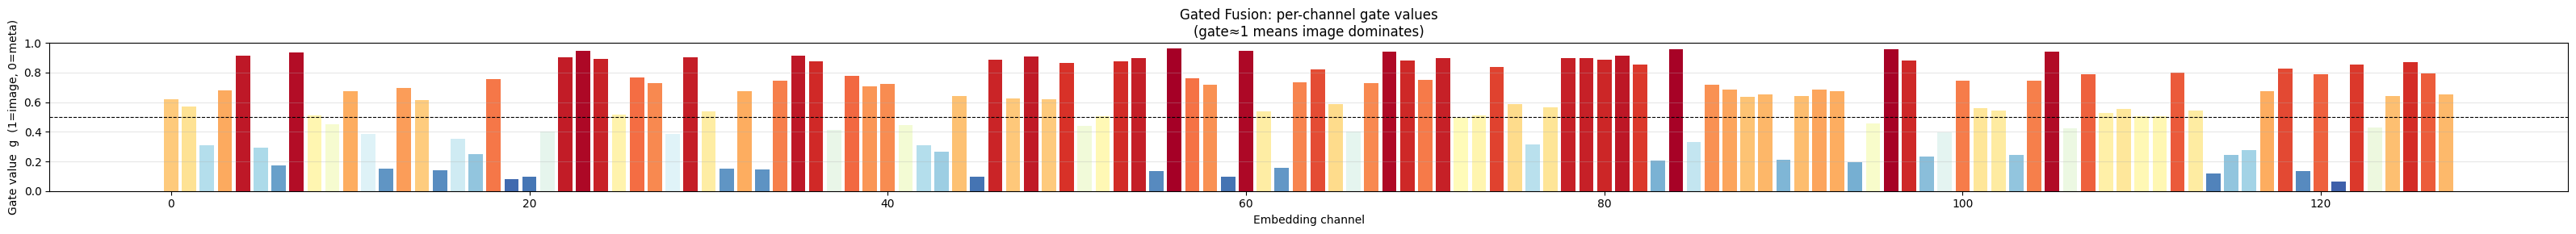

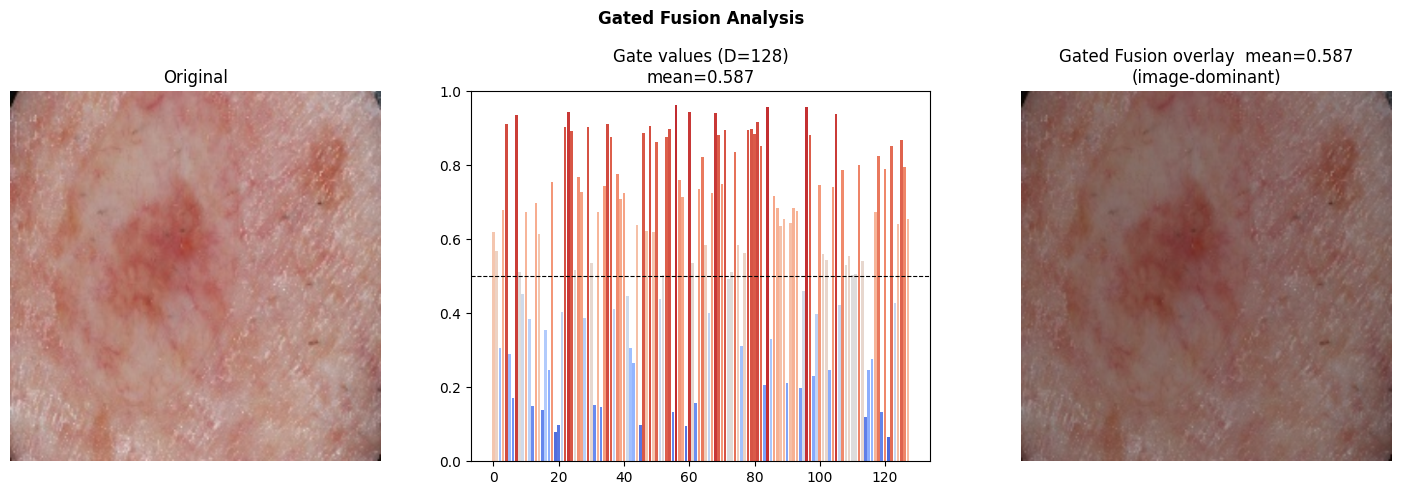

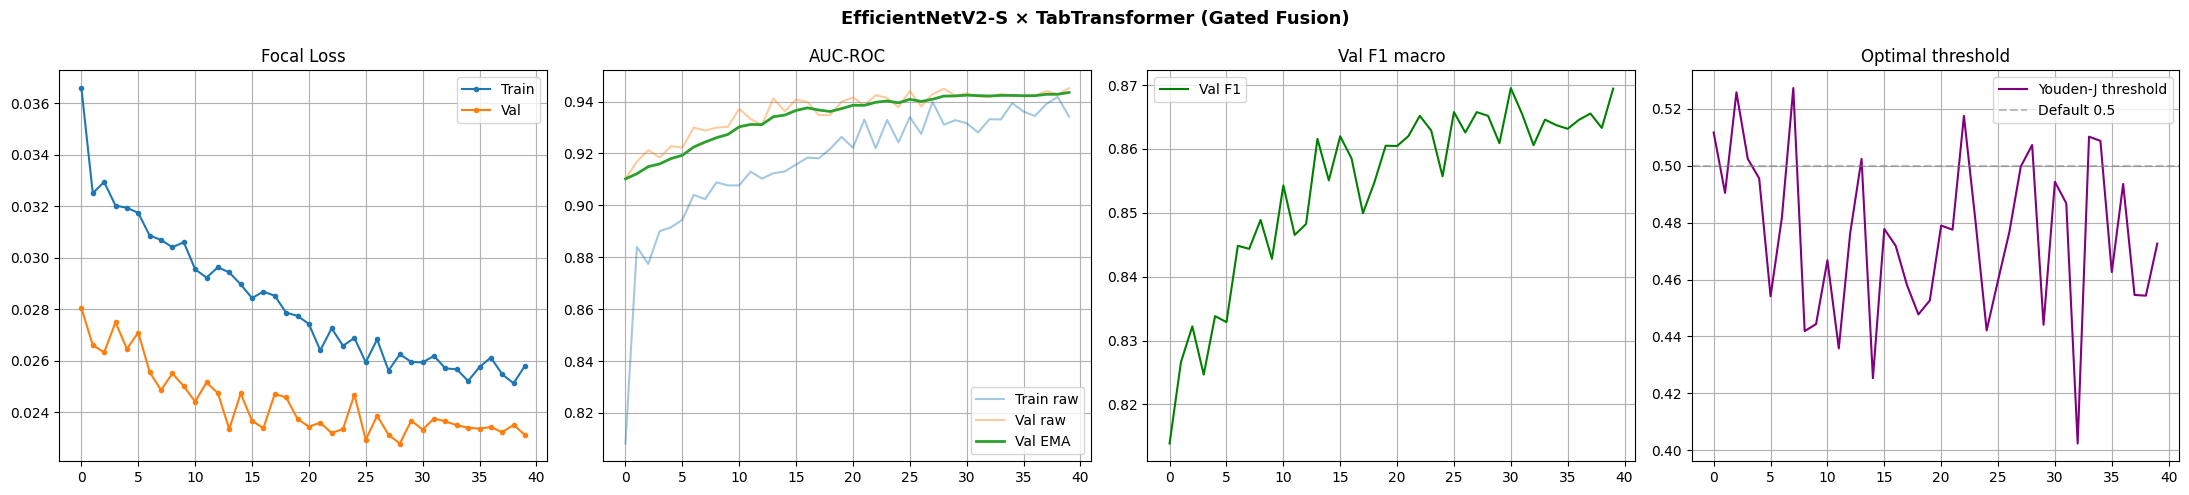

  Saved: /kaggle/working/efficient_v2_outputs/training_curves_efficient_v2.png


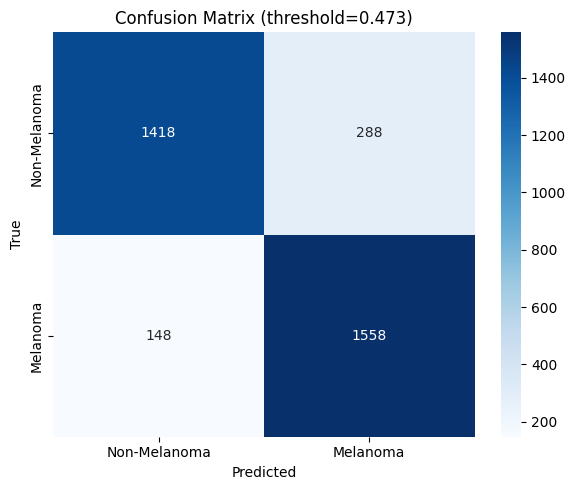

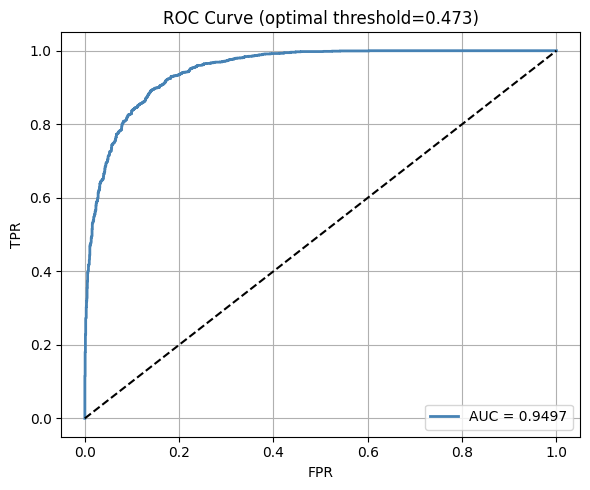


═════════════════════════════════════════════════════════════════
  XAI Suite  (Single run)
  Running on : CPU  (GPU left free — no OOM risk)
  Methods    : Grad-CAM++, IG (multimodal), Attention Rollout, Gate Values
  Samples    : 5
═════════════════════════════════════════════════════════════════


  ── Sample 1/5  (Melanoma) ──


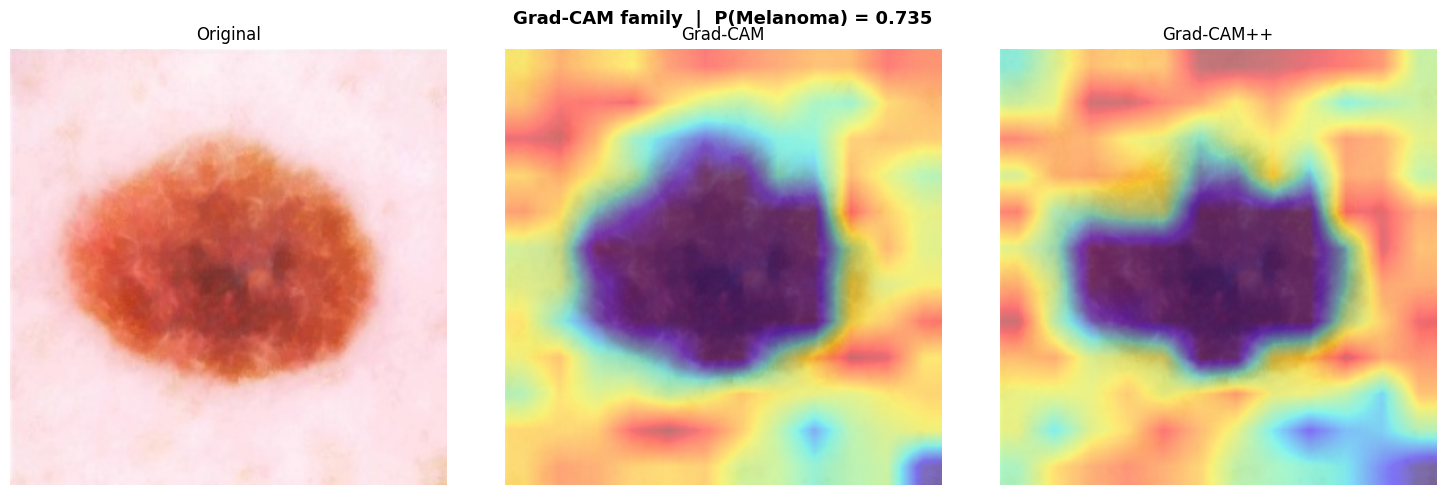

  ✔ /kaggle/working/efficient_v2_outputs/xai_gradcam_s1.png


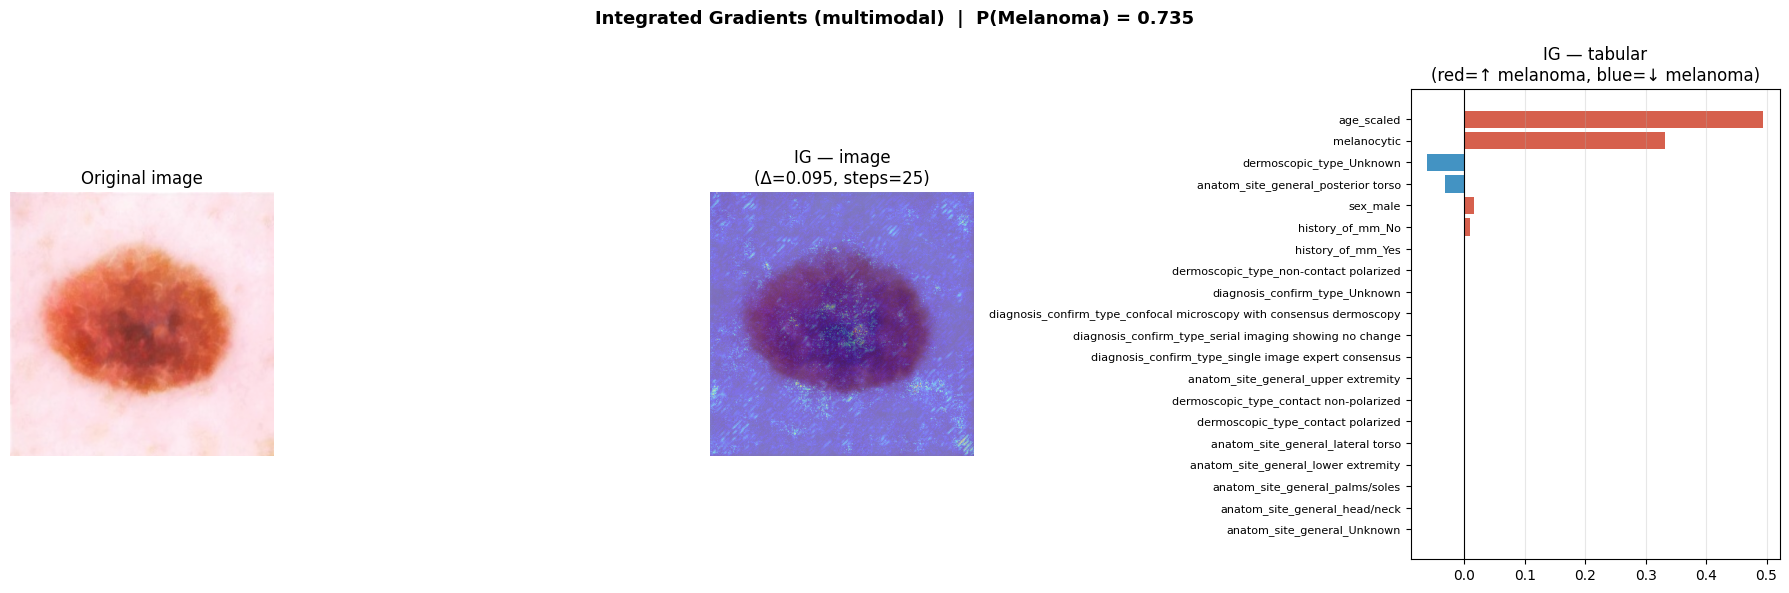

  ✔ /kaggle/working/efficient_v2_outputs/xai_integrated_gradients_s1.png


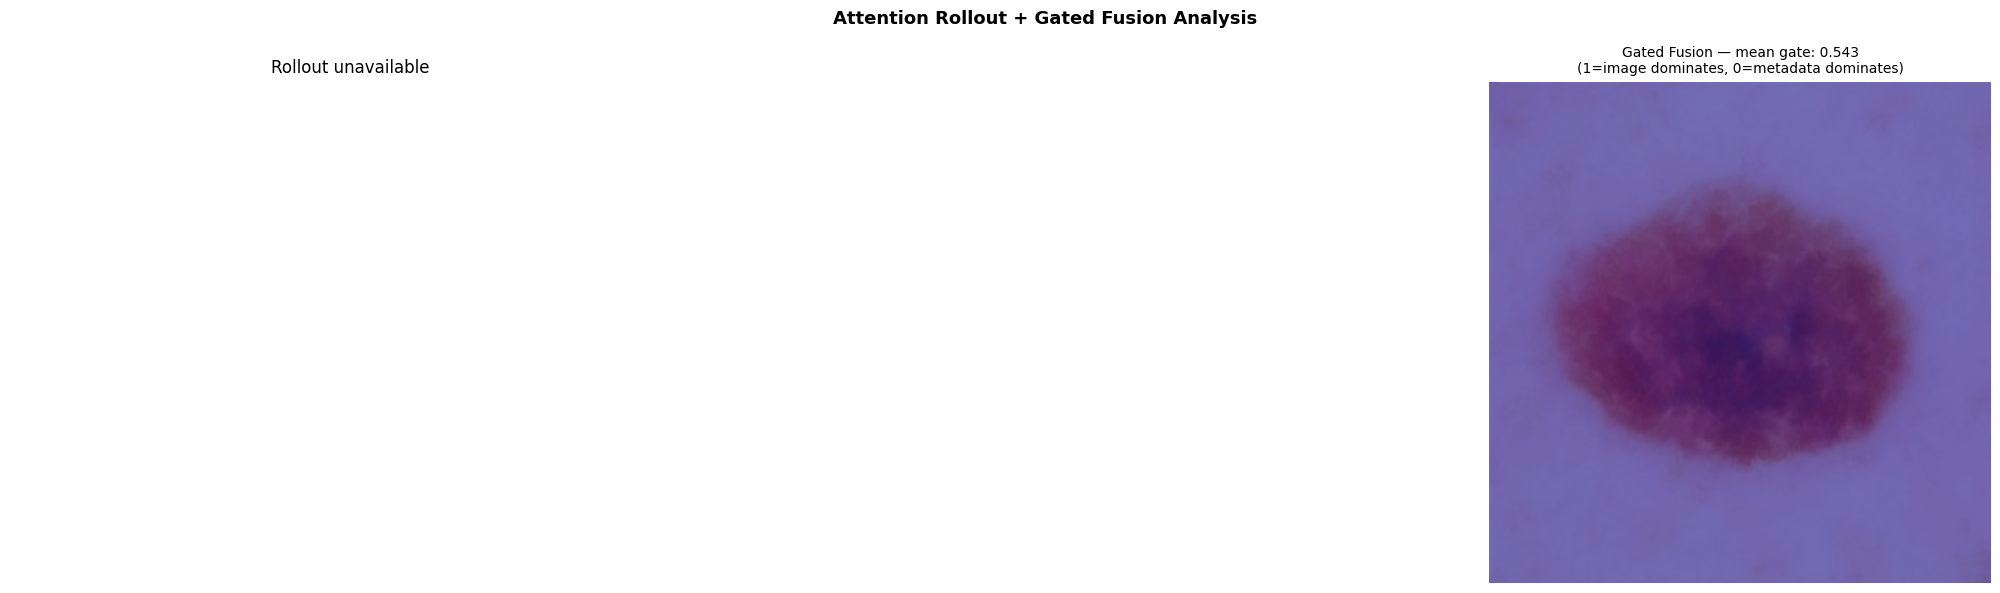

  ✔ /kaggle/working/efficient_v2_outputs/xai_attention_rollout_s1.png


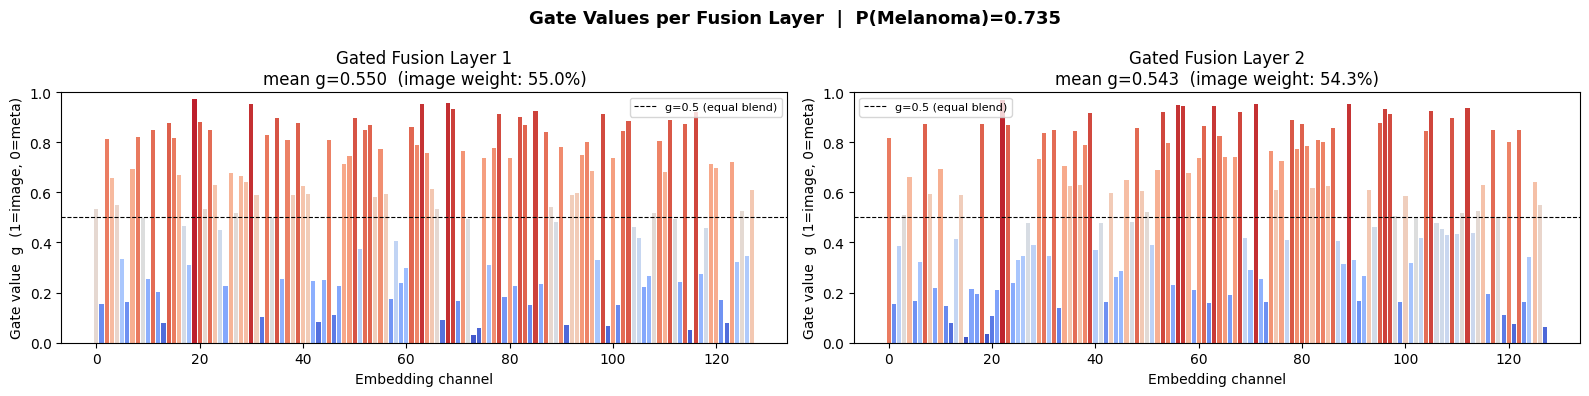

  ✔ /kaggle/working/efficient_v2_outputs/xai_gate_values_s1.png

  ── Sample 2/5  (Non-Melanoma) ──


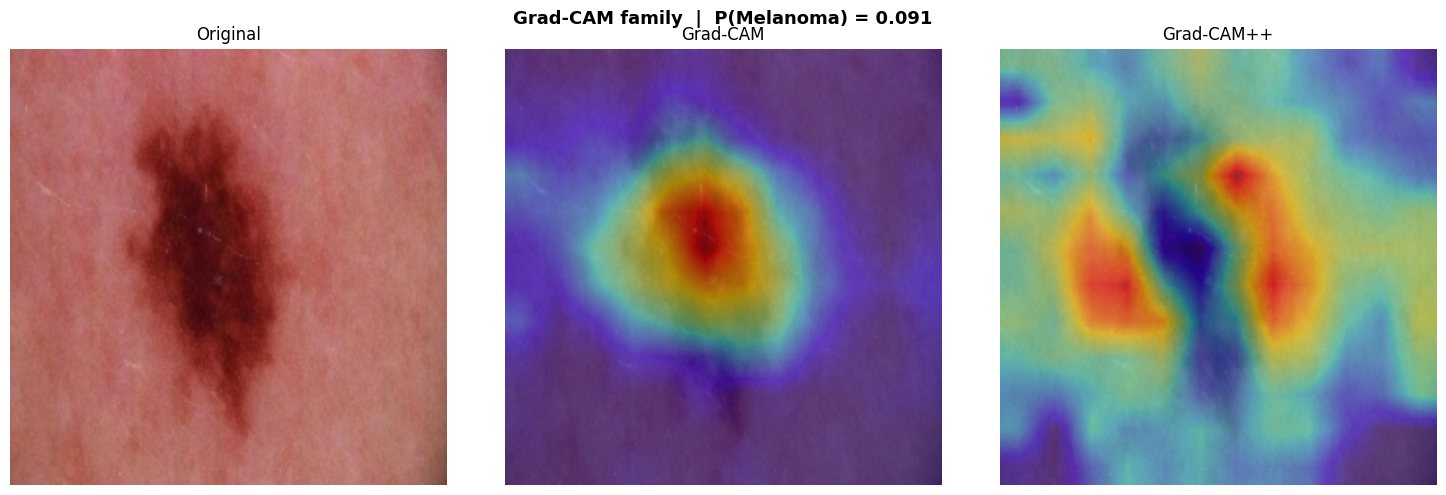

  ✔ /kaggle/working/efficient_v2_outputs/xai_gradcam_s2.png


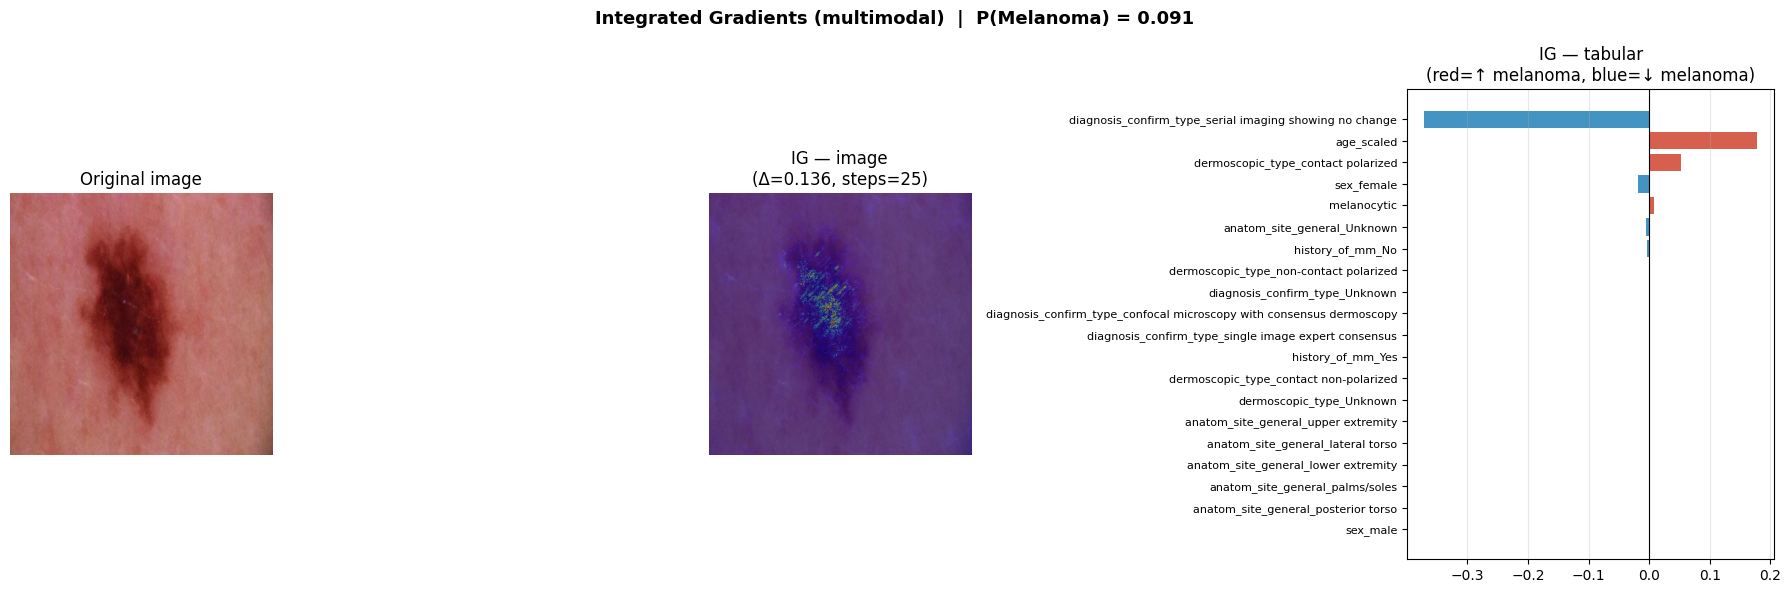

  ✔ /kaggle/working/efficient_v2_outputs/xai_integrated_gradients_s2.png


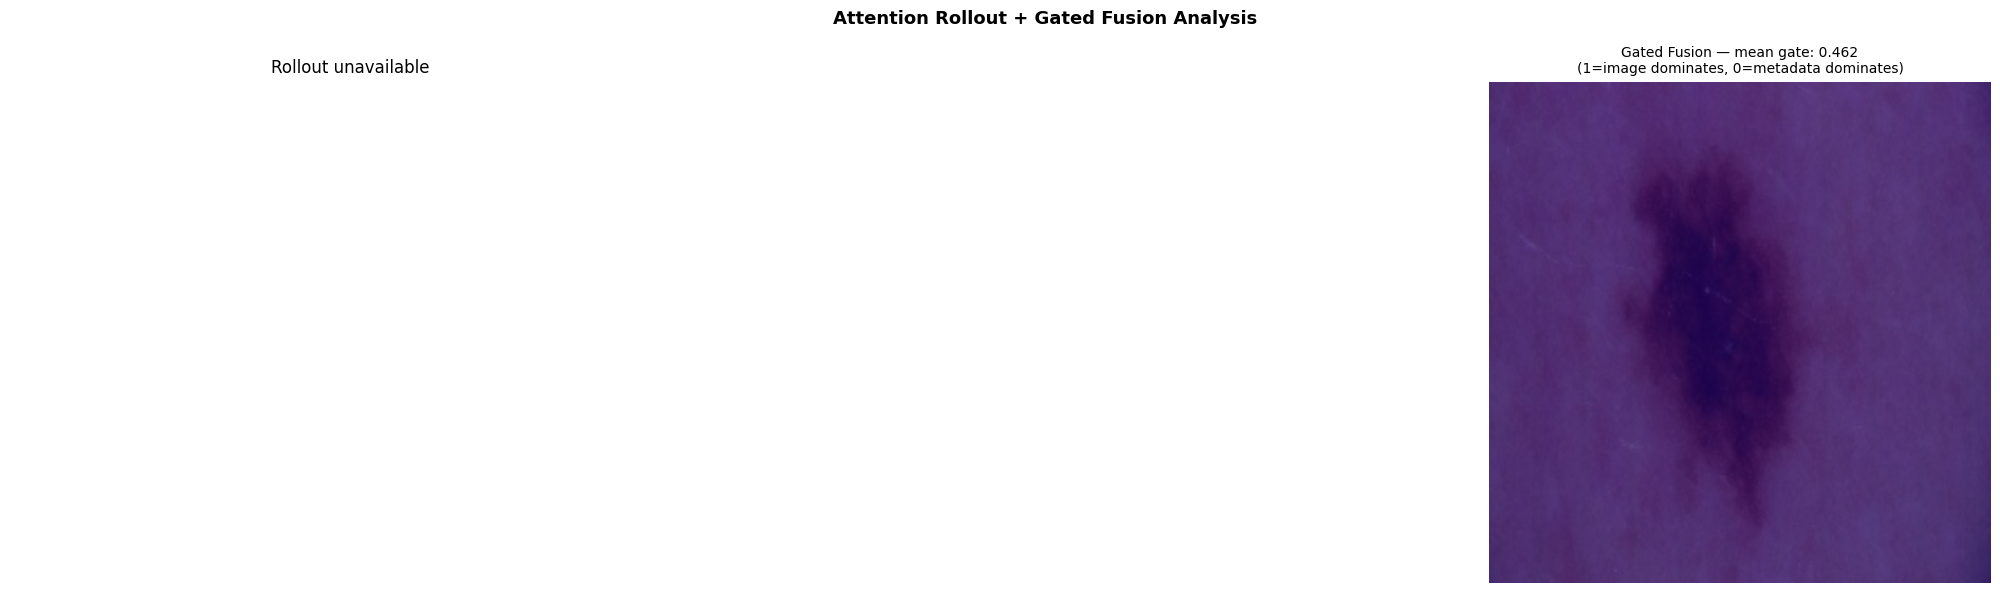

  ✔ /kaggle/working/efficient_v2_outputs/xai_attention_rollout_s2.png


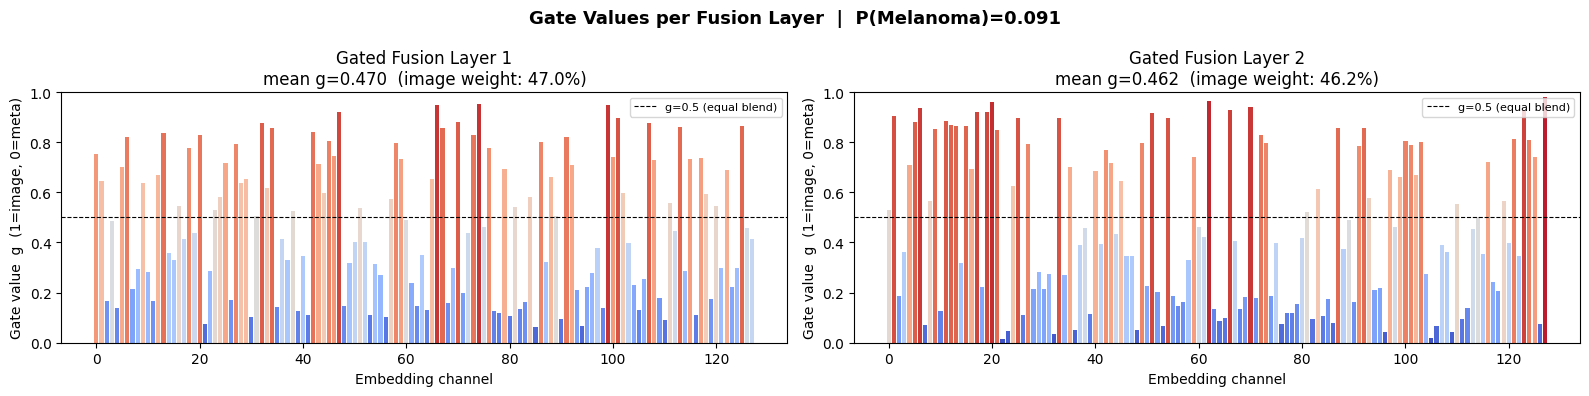

  ✔ /kaggle/working/efficient_v2_outputs/xai_gate_values_s2.png

  ── Sample 3/5  (Melanoma) ──


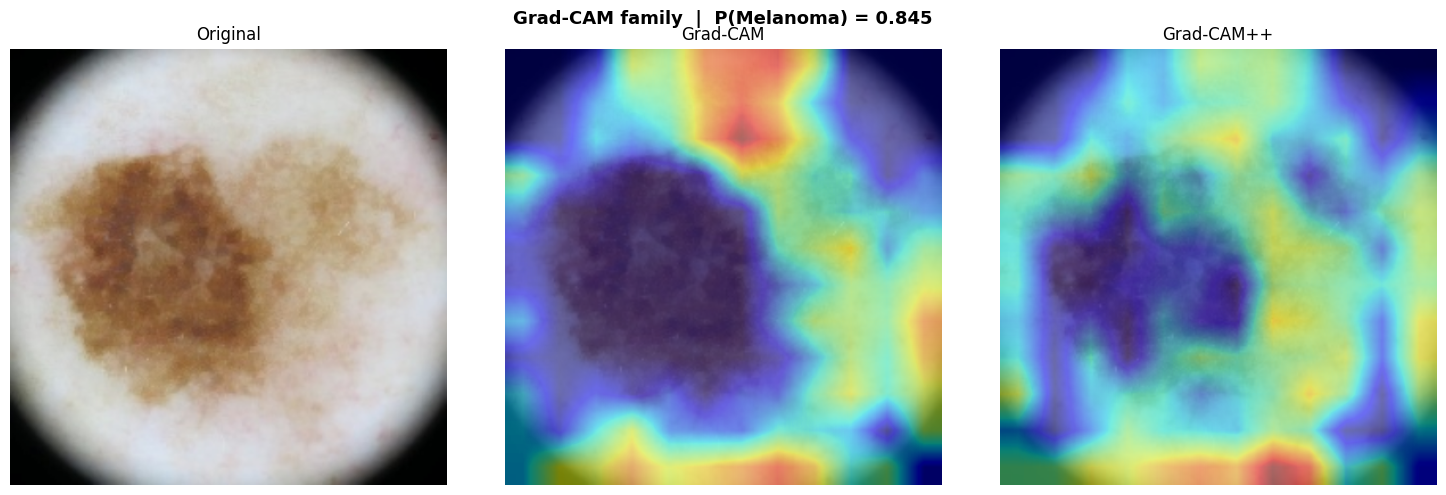

  ✔ /kaggle/working/efficient_v2_outputs/xai_gradcam_s3.png


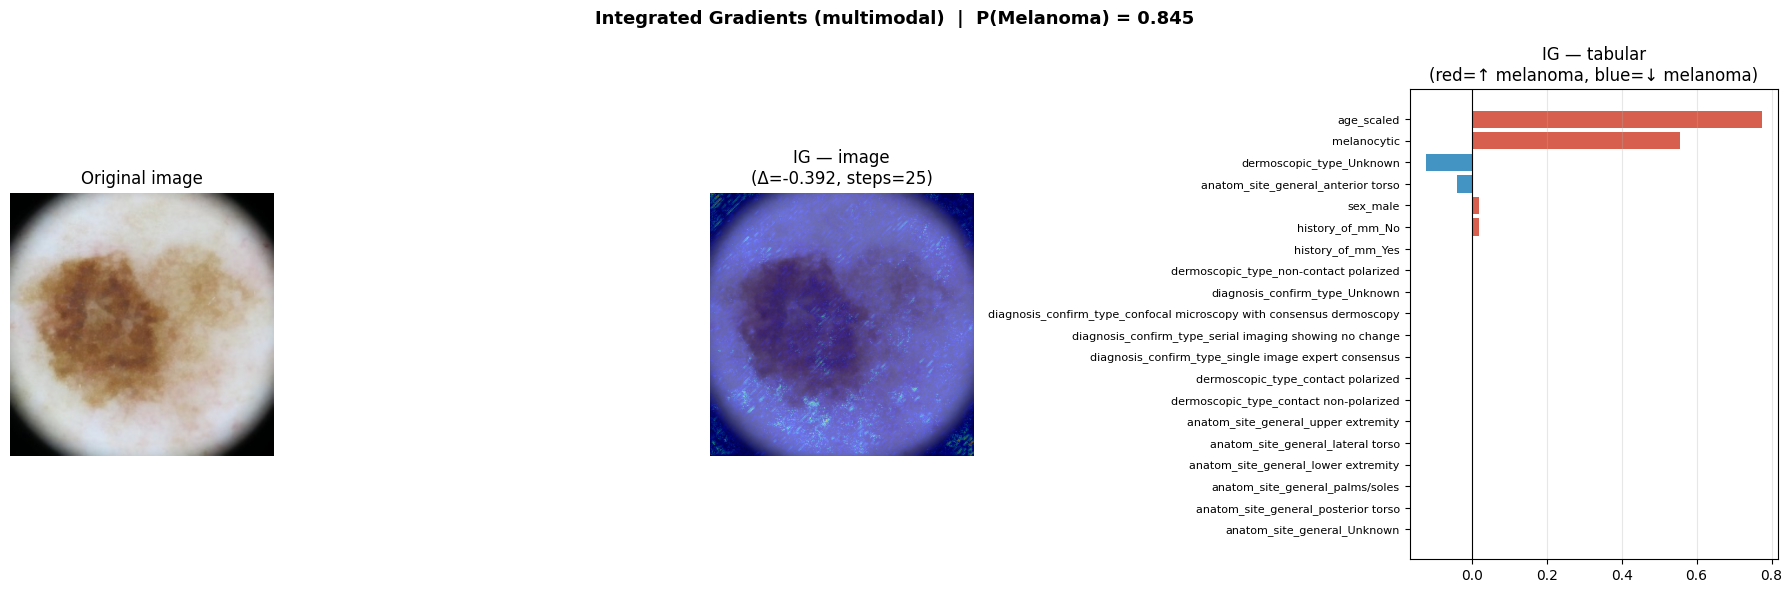

  ✔ /kaggle/working/efficient_v2_outputs/xai_integrated_gradients_s3.png


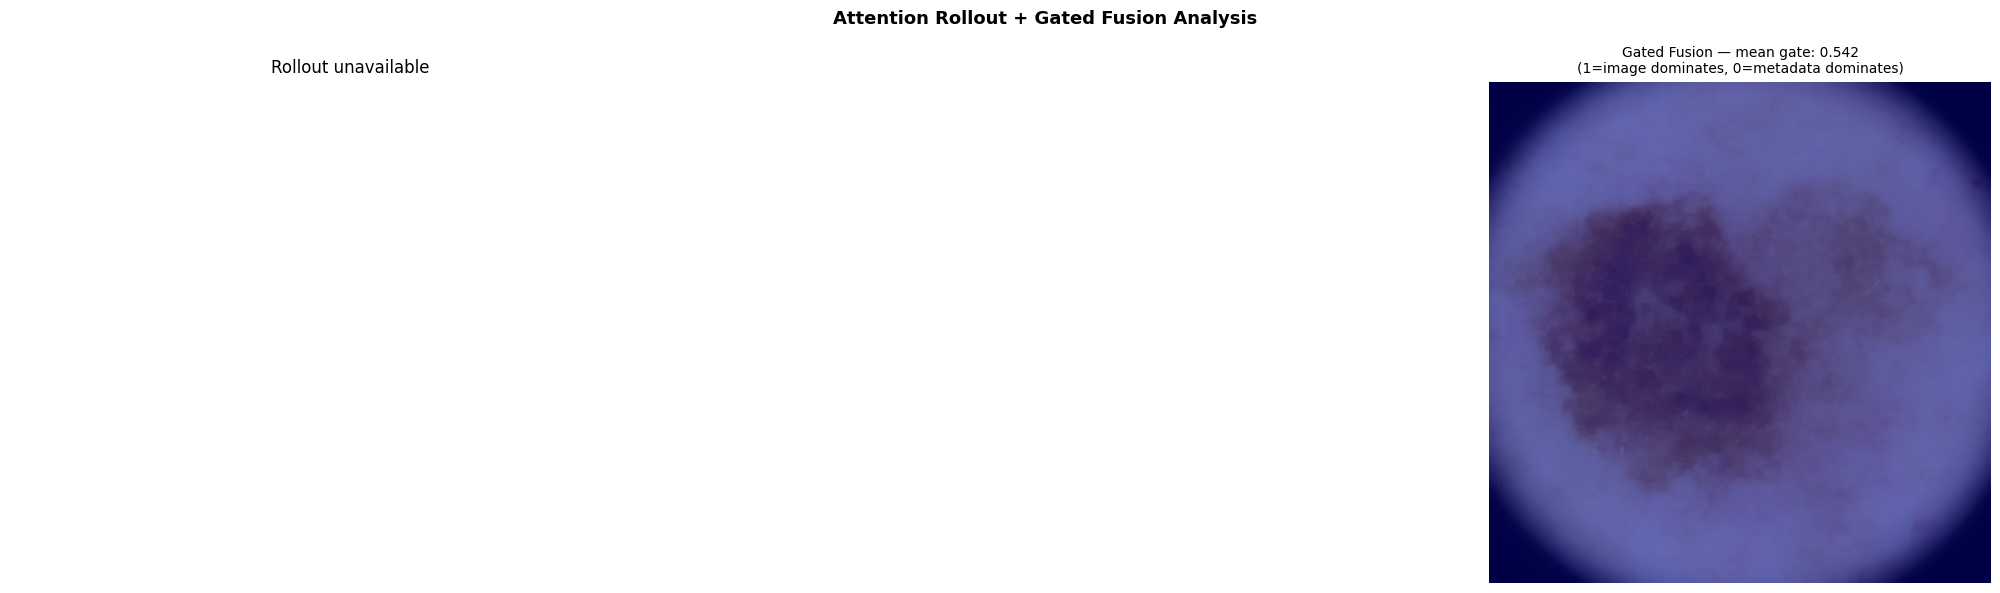

  ✔ /kaggle/working/efficient_v2_outputs/xai_attention_rollout_s3.png


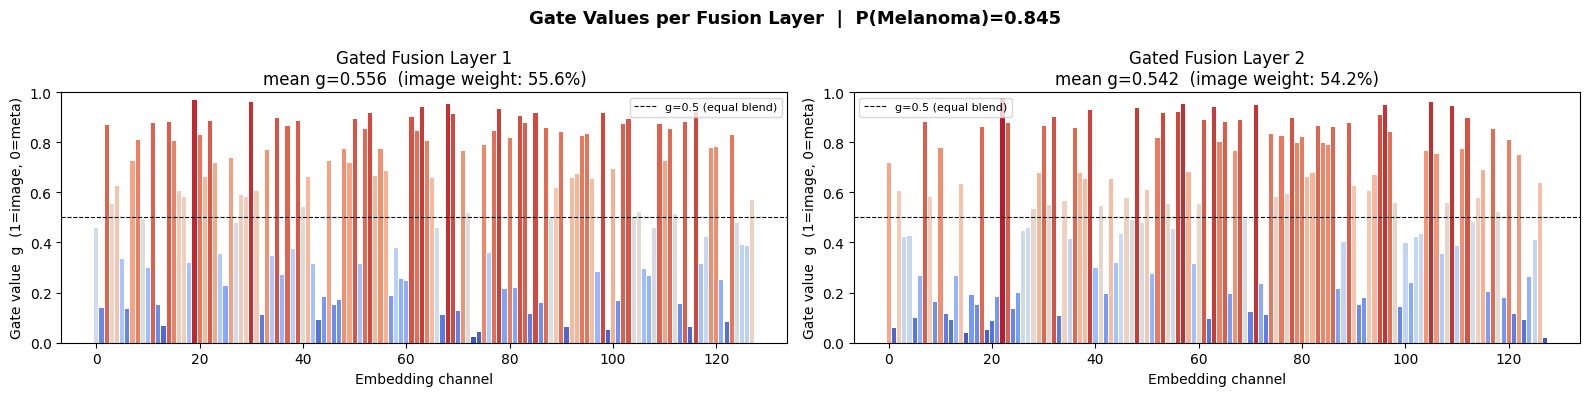

  ✔ /kaggle/working/efficient_v2_outputs/xai_gate_values_s3.png

  ── Sample 4/5  (Melanoma) ──


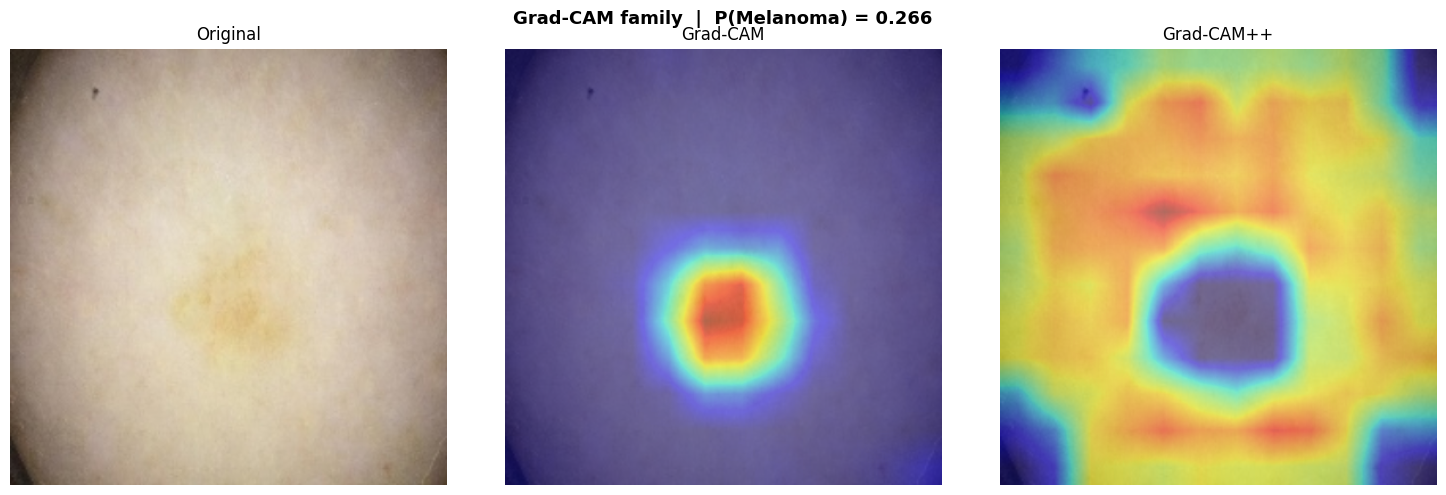

  ✔ /kaggle/working/efficient_v2_outputs/xai_gradcam_s4.png


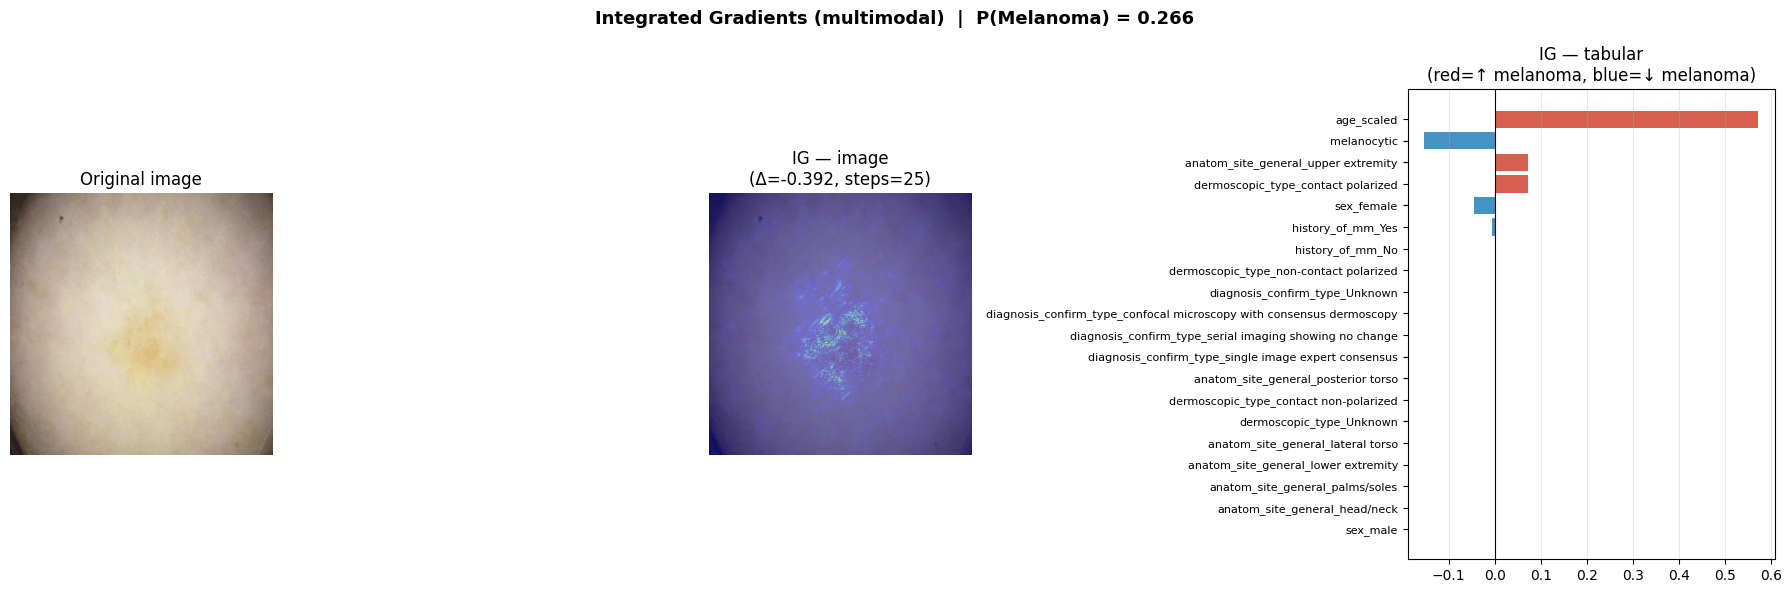

  ✔ /kaggle/working/efficient_v2_outputs/xai_integrated_gradients_s4.png


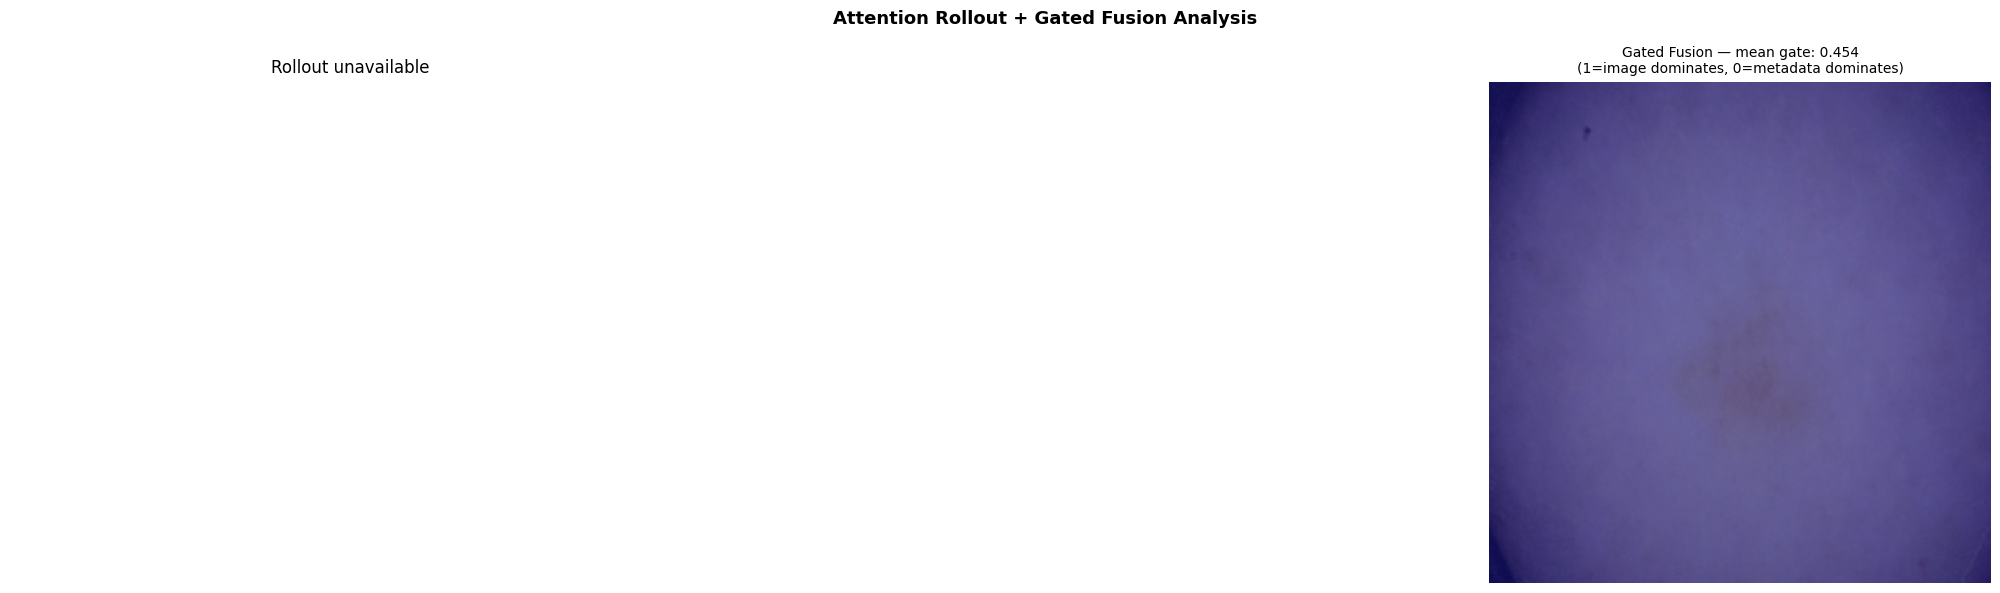

  ✔ /kaggle/working/efficient_v2_outputs/xai_attention_rollout_s4.png


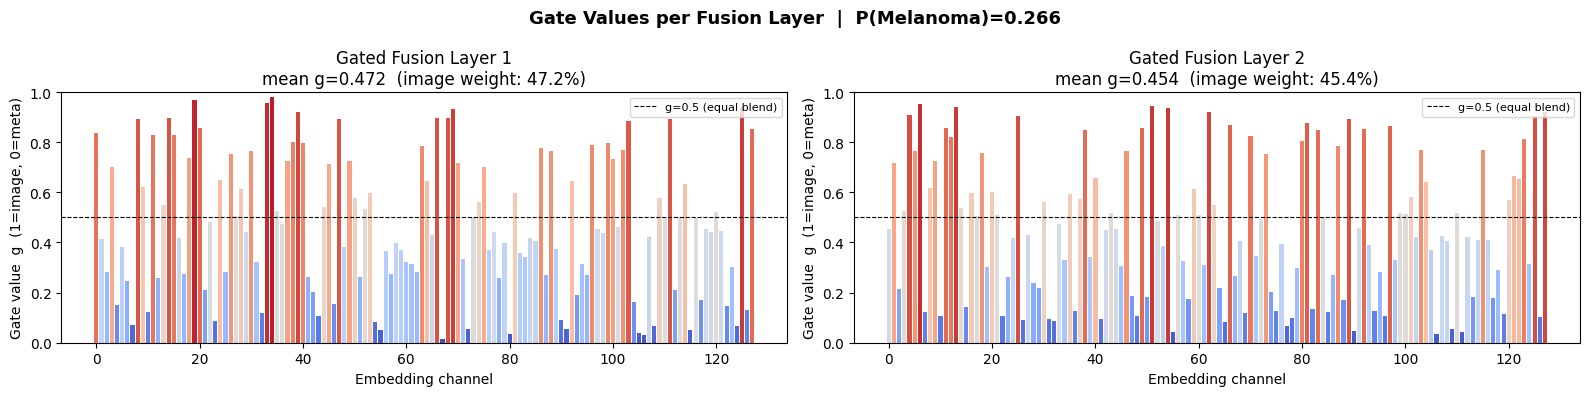

  ✔ /kaggle/working/efficient_v2_outputs/xai_gate_values_s4.png

  ── Sample 5/5  (Non-Melanoma) ──


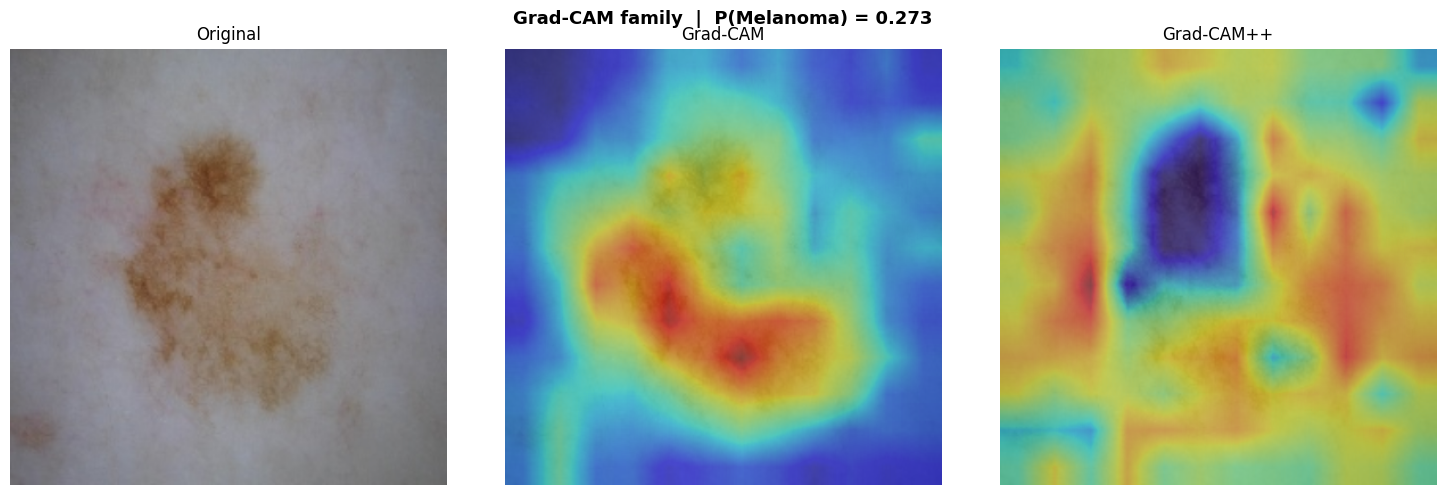

  ✔ /kaggle/working/efficient_v2_outputs/xai_gradcam_s5.png


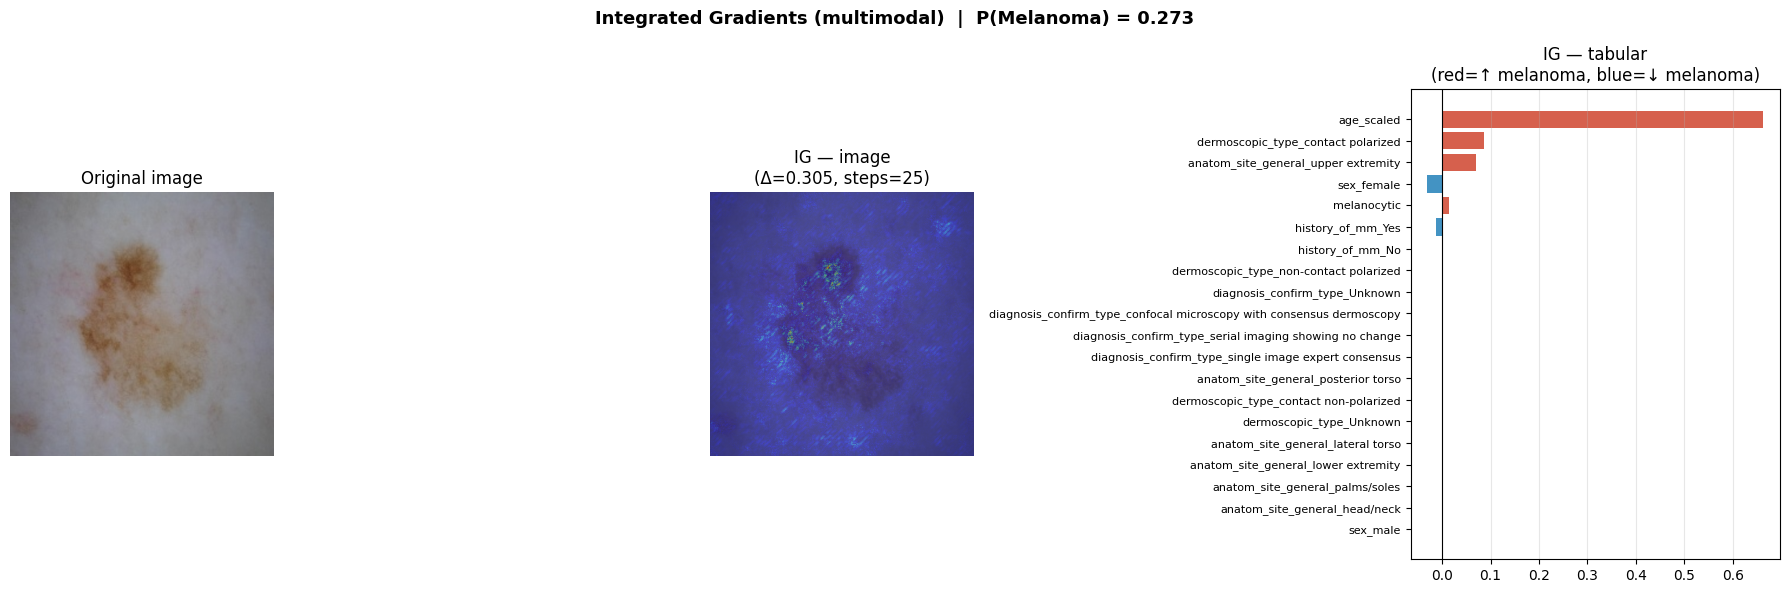

  ✔ /kaggle/working/efficient_v2_outputs/xai_integrated_gradients_s5.png


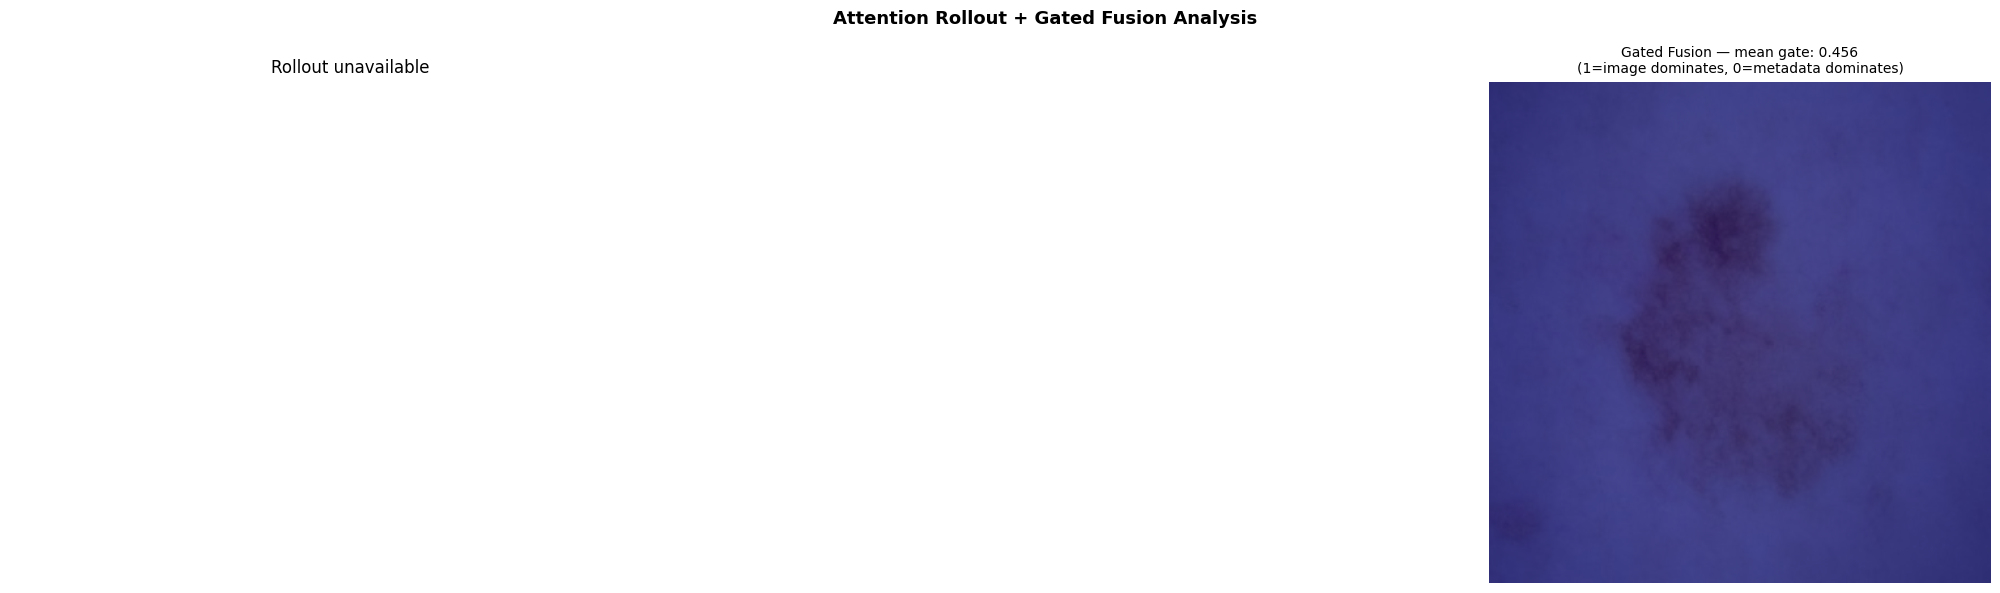

  ✔ /kaggle/working/efficient_v2_outputs/xai_attention_rollout_s5.png


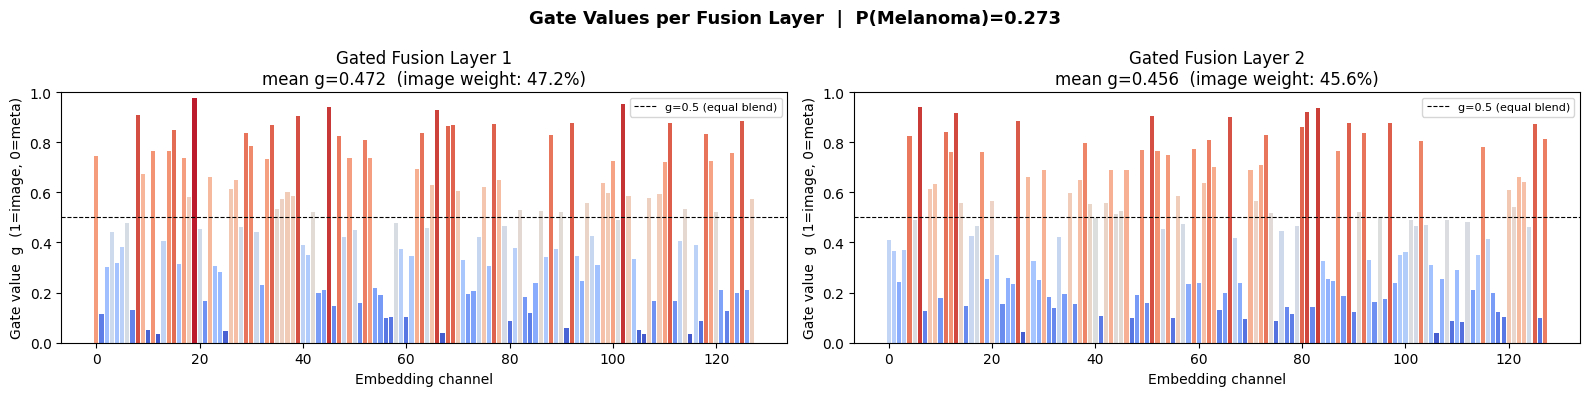

  ✔ /kaggle/working/efficient_v2_outputs/xai_gate_values_s5.png

  ✅ XAI outputs saved to: /kaggle/working/efficient_v2_outputs/
  ▶  Run the SHAP cell next for global feature importance.

  📄 val_df saved → /kaggle/working/efficient_v2_outputs/val_df.csv
  ▶  Run the SHAP cell next for global feature importance.

All outputs saved to: /kaggle/working/efficient_v2_outputs/


In [13]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — Main (run this cell to start everything)                  ║
# ╚══════════════════════════════════════════════════════════════════════╝

def main():
    print("\n" + "═" * 65)
    print("  ISIC-DICM-17K  |  EfficientNetV2-S + TabTransformer")
    print("  Gated Fusion  —  v2 FIXED  +  XAI (CPU-safe, no SHAP)")
    print("═" * 65)

    df = pd.read_csv(CFG.CSV_PATH)

    def extract_id(filename):
        match = re.search(r"(\d{7})", str(filename))
        return f"ISIC_{match.group(1)}.jpg" if match else filename

    print(f"Normalizing {len(df)} image names…")
    df[CFG.IMG_COL] = df[CFG.IMG_COL].apply(extract_id)

    meta_cols = [c for c in df.columns if c not in CFG.DROP_COLS]
    validate_features(df, meta_cols)

    if CFG.USE_KFOLD:
        print(f"\nRunning {CFG.N_FOLDS}-Fold Stratified CV")
        skf        = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True,
                                     random_state=CFG.SEED)
        fold_aucs, fold_f1s = [], []
        oof_probs  = np.zeros(len(df))
        oof_labels = np.zeros(len(df))

        for fold, (tr_idx, vl_idx) in enumerate(
                skf.split(df, df[CFG.TARGET_COL]), 1):
            model, auc, f1, probs, labels = run_training(
                df.iloc[tr_idx], df.iloc[vl_idx], meta_cols, fold=fold)
            fold_aucs.append(auc);  fold_f1s.append(f1)
            oof_probs[vl_idx]  = probs
            oof_labels[vl_idx] = labels

        oof_auc = roc_auc_score(oof_labels, oof_probs)
        print(f"\n{'═'*65}")
        print(f"  K-FOLD SUMMARY")
        print(f"  Per-fold AUC  : {[f'{a:.4f}' for a in fold_aucs]}")
        print(f"  Mean AUC      : {np.mean(fold_aucs):.4f} "
              f"± {np.std(fold_aucs):.4f}")
        print(f"  OOF AUC       : {oof_auc:.4f}")
        print(f"  Mean F1 macro : {np.mean(fold_f1s):.4f}")
        print(f"{'═'*65}")
        pd.DataFrame({"label": oof_labels, "prob_melanoma": oof_probs}).to_csv(
            os.path.join(CFG.OUTPUT_DIR, "oof_predictions_efficient_v2.csv"),
            index=False)
    else:
        train_df, val_df = train_test_split(
            df, test_size=0.2,
            stratify=df[CFG.TARGET_COL],
            random_state=CFG.SEED)
        run_training(train_df, val_df, meta_cols)

    print(f"\nAll outputs saved to: {CFG.OUTPUT_DIR}")


main()

Loading checkpoint: /kaggle/working/efficient_v2_outputs/best_efficient_v2_model.pth
  EfficientNetV2-S feature map: 1280×12×12 → 144 spatial tokens
  Model Architecture & Weights Loaded ✔

Searching for a 'Median' Representative Image (P ≈ 0.5)...
  Found representative image with P(Melanoma) ≈ 0.953

Building SHAP Background (60 rows)...
Explaining 20 samples with 50 iterations...


  0%|          | 0/20 [00:00<?, ?it/s]

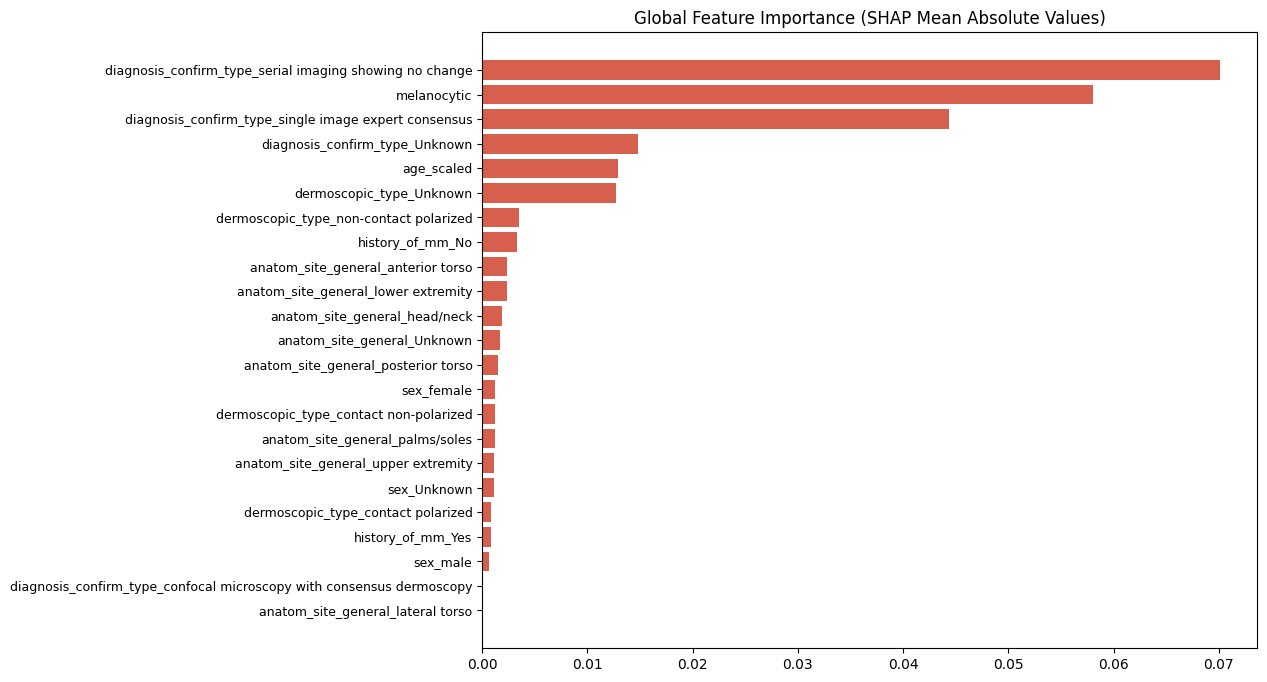

  ✔ saved → /kaggle/working/efficient_v2_outputs/xai_shap_bar_optimized.png


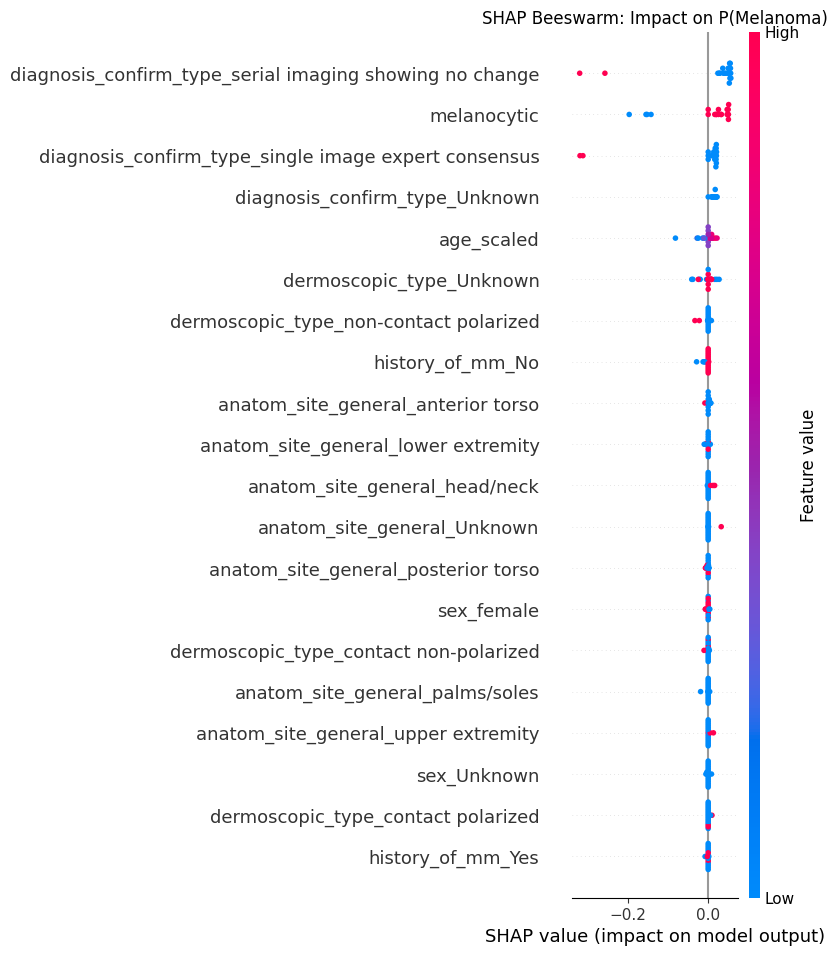

  ✔ saved → /kaggle/working/efficient_v2_outputs/xai_shap_beeswarm_optimized.png

✅ SHAP analysis complete. Outputs saved to /kaggle/working/efficient_v2_outputs/


In [18]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║           SHAP — Global Clinical Feature Importance (Optimized)              ║
# ║      Run this cell AFTER the training cell has finished successfully.        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os, gc, glob, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader
import shap

warnings.filterwarnings("ignore")

# ─── SHAP Configuration ───────────────────────────────────────────────────────
OUTPUT_DIR      = "/kaggle/working/efficient_v2_outputs/"
IMAGES_DIR      = "/kaggle/input/datasets/ahmedmohsen2005/xai-preprocessed-skin-lesion-17k-dataset/final_processed_images"
IMG_COL         = "image"
TARGET_COL      = "class"
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"

SHAP_BACKGROUND = 60    # rows for background distribution
SHAP_NSAMPLES   = 50    # KernelExplainer iterations per row
SHAP_EXPLAIN    = 20    # number of val rows to explain
SHAP_TOP_K      = 25    # features shown in plots
SHAP_BATCH_SIZE = 32    # max batch size for SHAP forward passes to prevent OOM

IMG_SIZE = 384
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

_XAI_TF = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

def _save_fig(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  ✔ saved → {path}")

# ─── 1. Load Checkpoint & Model ───────────────────────────────────────────────
ckpt_candidates = sorted(glob.glob(os.path.join(OUTPUT_DIR, "best_efficient_v2_*.pth")))
if not ckpt_candidates: raise FileNotFoundError("No checkpoint found.")
CKPT_PATH = ckpt_candidates[0]
print(f"Loading checkpoint: {CKPT_PATH}")

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
meta_cols = list(ckpt["meta_cols"])
meta_dim  = ckpt["meta_dim"]

try:
    model = EfficientFusionModel(meta_dim=meta_dim).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    print("  Model Architecture & Weights Loaded ✔")
except NameError:
    print("❌ Error: EfficientFusionModel class not defined in this session.")
    raise

# ─── 2. Load Data & Find "Median" Representative Image ──────────────────────
val_df_candidates = sorted(glob.glob(os.path.join(OUTPUT_DIR, "val_df*.csv")))
if not val_df_candidates: raise FileNotFoundError("val_df.csv missing.")
val_df = pd.read_csv(val_df_candidates[0])

print("\nSearching for a 'Median' Representative Image (P ≈ 0.5)...")
# We use a small subset to find an image where the model is uncertain
temp_ds = ISICDataset(val_df.sample(min(200, len(val_df))), IMAGES_DIR, augment=False)
temp_loader = DataLoader(temp_ds, batch_size=32, shuffle=False)

median_img = None
best_diff = 1.0

with torch.no_grad():
    for imgs, metas, _ in temp_loader:
        logits = model(imgs.to(DEVICE), metas.to(DEVICE))
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        
        # Find index closest to 0.5 in this batch
        idx = np.argmin(np.abs(probs - 0.5))
        diff = abs(probs[idx] - 0.5)
        
        if diff < best_diff:
            best_diff = diff
            median_img = imgs[idx].unsqueeze(0).to(DEVICE)
            if best_diff < 0.05: break # Good enough

if median_img is None:
    print("  ! Could not find median image, defaulting to first available.")
    median_img = _XAI_TF(Image.open(os.path.join(IMAGES_DIR, val_df.iloc[0][IMG_COL])).convert("RGB")).unsqueeze(0).to(DEVICE)
else:
    print(f"  Found representative image with P(Melanoma) ≈ {0.5 + (0.5-best_diff if best_diff > 0 else best_diff):.3f}")

# ─── 3. Define Batched Prediction Wrapper ─────────────────────────────────────
@torch.no_grad()
def _predict_meta_batched(meta_np):
    """
    Optimized prediction wrapper that processes SHAP samples in small batches
    to prevent GPU OOM when SHAP_NSAMPLES or SHAP_EXPLAIN are high.
    """
    n_samples = meta_np.shape[0]
    all_probs = []
    
    for i in range(0, n_samples, SHAP_BATCH_SIZE):
        batch_meta = torch.tensor(meta_np[i:i+SHAP_BATCH_SIZE], dtype=torch.float32).to(DEVICE)
        batch_img  = median_img.expand(batch_meta.shape[0], -1, -1, -1)
        
        logits = model(batch_img, batch_meta)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        all_probs.append(probs)
        
    return np.concatenate(all_probs)

# ─── 4. Run SHAP KernelExplainer ──────────────────────────────────────────────
print(f"\nBuilding SHAP Background ({SHAP_BACKGROUND} rows)...")
bg_meta = val_df[meta_cols].sample(min(SHAP_BACKGROUND, len(val_df)), random_state=42).values.astype(np.float32)
explainer = shap.KernelExplainer(_predict_meta_batched, bg_meta)

print(f"Explaining {SHAP_EXPLAIN} samples with {SHAP_NSAMPLES} iterations...")
exp_rows = val_df.sample(min(SHAP_EXPLAIN, len(val_df)), random_state=0)
exp_meta = exp_rows[meta_cols].values.astype(np.float32)

shap_vals = explainer.shap_values(exp_meta, nsamples=SHAP_NSAMPLES, silent=False)

# ─── 5. Visualization & Export ────────────────────────────────────────────────
mean_abs = np.abs(shap_vals).mean(axis=0)
order    = np.argsort(mean_abs)[::-1][:SHAP_TOP_K]

# Bar Chart
fig, ax = plt.subplots(figsize=(10, 8))
top_names = [meta_cols[i] for i in order][::-1]
ax.barh(range(len(top_names)), mean_abs[order][::-1], color="#d6604d")
ax.set_yticks(range(len(top_names)))
ax.set_yticklabels(top_names, fontsize=9)
ax.set_title("Global Feature Importance (SHAP Mean Absolute Values)")
_save_fig(fig, "xai_shap_bar_optimized.png")

# Beeswarm Summary
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals[:, order], exp_meta[:, order], feature_names=[meta_cols[i] for i in order], show=False)
plt.title("SHAP Beeswarm: Impact on P(Melanoma)")
_save_fig(plt.gcf(), "xai_shap_beeswarm_optimized.png")

# CSV Export
shap_df = pd.DataFrame({"feature": meta_cols, "mean_abs_shap": mean_abs}).sort_values("mean_abs_shap", ascending=False)
shap_df.to_csv(os.path.join(OUTPUT_DIR, "xai_shap_importance.csv"), index=False)

gc.collect()
if DEVICE == "cuda": torch.cuda.empty_cache()
print(f"\n✅ SHAP analysis complete. Outputs saved to {OUTPUT_DIR}")